# Deep Learning — Module 2: Training & Optimization · Part 2
## Optimizers & Learning Rate Scheduling

> Every concept in three layers: **Intuition → Math → Code**

---

## Table of Contents

| Section | Topic |
|---------|-------|
| **1** | Gradient Descent Variants (Batch, Mini-batch, SGD) |
| **2** | Momentum — Escaping Ravines |
| **3** | AdaGrad — Per-parameter Learning Rates |
| **4** | RMSProp — Fixing AdaGrad's Fading Memory |
| **5** | Adam — The Industry Default |
| **6** | AdamW — Weight Decay Done Right |
| **7** | Optimizer Trajectory Visualization |
| **8** | LR Scheduling (Step, Cosine, Warmup, LR Finder) |
| **9** | PyTorch Optimizer & Scheduler Demo |
| **10** | Master Interview Q&A Cheatsheet |


In [19]:
# ── All imports — run this first ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
    "axes.prop_cycle": plt.cycler(color=[
        "#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3","#8C8C8C"
    ])
})
print("Imports ready ✓")


Imports ready ✓


## 1. Gradient Descent Variants

### Intuition: Hiking Down a Mountain
You're hiking down a misty mountain (the loss landscape) trying to reach the valley (minimum loss).

Three strategies:
- **Batch GD** — look at the *entire map* before each step → most accurate direction, but very slow
- **Stochastic GD (SGD)** — take a step based on *one random observation* → fast but noisy
- **Mini-batch GD** — look at *a small sample* of the map → best of both worlds ✓

---

### Math

Let $W$ = current weights, $\eta$ = learning rate, $n$ = dataset size, $B$ = batch size.

#### Batch Gradient Descent
$$W \leftarrow W - \eta \cdot \frac{1}{n}\sum_{i=1}^{n}\nabla_W \mathcal{L}(x_i, y_i)$$
- Uses **all** $n$ examples per update
- Exact gradient → smooth convergence
- Impractical: won't fit ImageNet in RAM

#### Stochastic Gradient Descent (SGD)
$$W \leftarrow W - \eta \cdot \nabla_W \mathcal{L}(x_i, y_i) \quad \text{(one random sample)}$$
- **One** example per update → very noisy gradient estimate
- Fast but oscillates wildly
- The noise can help escape local minima

#### Mini-batch GD (what everyone calls "SGD" in practice)
$$W \leftarrow W - \eta \cdot \frac{1}{B}\sum_{i \in \text{batch}}\nabla_W \mathcal{L}(x_i, y_i)$$
- $B$ examples per update (typical: 32, 64, 128, 256)
- Good gradient estimate + GPU parallelism + memory feasible

| Variant | Gradient Quality | Speed | Memory | Noise |
|---------|-----------------|-------|--------|-------|
| Batch GD | ✅ Exact | ❌ Slow | ❌ High | ✅ None |
| SGD | ❌ Very noisy | ✅ Fast | ✅ Low | ❌ High |
| Mini-batch | ✅ Good approx | ✅ Fast | ✅ Medium | ✅ Moderate |

#### The Learning Rate Problem
Vanilla SGD has one global learning rate $\eta$ for all parameters. Problems:
1. Sparse features need larger updates; dense ones need smaller
2. Loss landscape may be steep in one direction and flat in another
3. Fixed $\eta$: either too fast (diverges) or too slow (stalls)

→ Everything from Section 2 onward fixes one or more of these problems.

#### Interview Questions: SGD
> **Q: Why do we use mini-batches instead of true SGD (batch=1)?**
> A: GPU parallelism — processing 32 samples simultaneously is nearly as fast as 1 sample on GPU. Also: better gradient estimates, less oscillation, faster wall-clock convergence.

> **Q: How does batch size affect a neural network's training dynamics and generalization?**
> A: Batch size is a critical hyperparameter that controls the trade-off between computational efficiency and stochasticity (noise). The effects can be broken down into three main categories:

> 1. Gradient Quality & Noise (Implicit Regularization)
Small Batches (e.g., 8, 16, 32): Provide a "noisy" estimate of the true gradient. Because the gradient jumps around, it acts as a form of implicit regularization. This noise helps the model "bounce out" of sharp local minima or narrow saddle points that might otherwise trap it.
Large Batches (e.g., 1024, 2048+): Provide a very accurate estimate of the gradient. While this leads to a smoother loss curve, the lack of noise makes it easier for the model to settle into the nearest minimum, even if that minimum is "sharp" and overfits to the training data.
> 2. Generalization: Flat vs. Sharp Minima
Sharp Minima (Large Batch): Large batches tend to converge to narrow, steep valleys in the loss landscape. Because these valleys are so thin, a tiny shift in data distribution (the difference between training and testing data) causes a massive jump in loss. Result: Poor generalization.
Flat Minima (Small Batch): Small batches tend to find broad, flat valleys. Even if the data shifts slightly at test time, the loss remains low because the "bottom" of the bowl is wide. Result: Better generalization and more robust models.
> 3. The "Linear Scaling Rule" for Learning Rates
When you increase the batch size, you perform fewer updates per epoch. To maintain the same training progress, you must scale the learning rate.

> **Rule:** If you increase the batch size by a factor of $k$, you should ideally increase the learning rate by $k$.
Example: If your model works well with batch_size=32 and lr=0.01, and you move to batch_size=128 (a $4\times$ increase), you should try lr=0.04.


> **Q: Can vanilla SGD get stuck in local minima?**
> A: In theory yes, but in practice deep networks have very few bad local minima — most critical points are saddle points. The real issue is saddle points and plateaus, not local minima.


### The Illusion of Local Minima

When learning about Gradient Descent, we are often shown 2D or 3D illustrations of a loss landscape filled with peaks and valleys. This creates a natural fear: **What if the optimizer rolls into a shallow valley and gets stuck, never finding the true bottom?**

While this is a valid concern for low-dimensional problems, **in modern deep neural networks (which have millions or billions of parameters), bad local minima are essentially a mathematical myth.** The real enemies of training are **Saddle Points** and **Plateaus**.

---

#### Core Definitions: The Loss Landscape

Before diving into why SGD stalls, let's define the key topographical features of a loss function:

1.  **Global Minimum:** 
    *   *Definition:* The absolute lowest point in the entire loss landscape. 
    *   *Intuition:* The bottom of the deepest ocean. This is the optimal set of weights where the model makes the fewest possible errors.
2.  **Local Minimum:** 
    *   *Definition:* A point where the loss is lower than all immediately surrounding points, but higher than the Global Minimum. The gradient here is exactly zero.
    *   *Intuition:* A crater on the side of a mountain. If a ball rolls in, it can't roll out without going uphill first.
3.  **Saddle Point:** 
    *   *Definition:* A point where the gradient is exactly zero, but it is a minimum in some directions and a maximum in others. 
    *   *Intuition:* The shape of a horse saddle or a mountain pass. If you walk forward/backward, you go up. If you walk left/right, you go down. If you stand dead center, it is perfectly flat.
4.  **Plateau:** 
    *   *Definition:* A vast, nearly flat region in the loss space where the gradient is extremely close to zero (but not exactly zero).
    *   *Intuition:* A massive, flat desert plains halfway down the mountain. 

---

#### Why Local Minima are Rare (The Curse of Dimensionality)

Why is it statistically impossible for a deep network to get trapped in a local minimum?

Imagine a network with just 2 parameters. For a point to be a true local minimum, the terrain must curve *upwards* in both the X and Y directions. This is pretty common.

Now imagine a modern network like GPT or ResNet with **1,000,000 parameters**. 
For a flat point to be a **true local minimum**, the terrain must curve *upwards* in **every single one of those 1,000,000 directions** simultaneously. If even *one* single direction curves downwards, it is not a minimum—it is a saddle point, and the optimizer can just step down that path to escape!

Statistically, the probability of tossing a coin 1,000,000 times and getting Heads every single time is zero. Similarly, finding a point that is a local minimum across millions of dimensions is practically impossible.

---

#### The Real Threat: Saddle Points and Plateaus

If local minima aren't the problem, why does SGD inexplicably stall and stop learning? 

**1. The Saddle Point Trap:**
Vanilla SGD calculates its next step by looking *only* at the current gradient (slope). 
$$W_{new} = W_{old} - (Learning\_Rate \times Gradient)$$
If SGD lands exactly in the dead center of a saddle point, the gradient is exactly `0`. 
$$W_{new} = W_{old} - (Learning\_Rate \times 0) = W_{old}$$
The weights stop updating entirely. The model thinks it has finished learning, even though a steep drop-off is just an inch to the left.

**2. The Plateau Crawl:**
On a massive, flat plateau, the gradient isn't exactly `0`, but it is extremely small (e.g., `0.0000001`). 
Because SGD takes steps proportional to the gradient, it begins taking microscopic steps. The loss flatlines, and training appears to be completely stuck, even though it is technically still moving.

**The Solution:**
This is why we use advanced optimizers like **SGD with Momentum** or **Adam**. They incorporate "velocity." If a bowling ball rolls down a hill and hits a flat plateau or a saddle point, its accumulated momentum carries it straight across the flat terrain until it finds the slope again. Vanilla SGD, acting like a feather, just stops.

---

## 2. Momentum — Escaping Ravines

### Intuition: The Bowling Ball vs. The Feather

To understand why Vanilla SGD struggles and why Momentum fixes it, we need to understand the concept of a **Ravine** (also known as pathological curvature).

Imagine a winding river canyon or a long, narrow ravine. 
*   **The Steep Walls:** If you walk left or right, the walls go straight up. The gradient (slope) here is extremely high.
*   **The Valley Floor:** If you walk forward along the riverbed towards the ocean (the global minimum), the floor is almost completely flat. The gradient here is extremely low.

#### **The Problem with Vanilla SGD (The Feather)**
Vanilla SGD acts like a feather floating in the wind, only moving based on the exact slope directly underneath it at that precise millisecond. 
When SGD enters a ravine:
1.  It feels the massive slope of the steep walls and takes a huge leap horizontally. 
2.  It overshoots, lands high up on the *opposite* wall, feels that massive slope, and leaps all the way back.
3.  Because the forward slope (the valley floor) is so flat, its forward progress is microscopic.
**Result:** SGD **zig-zags wildly** side-to-side across the ravine, wasting all its energy and taking forever to actually move forward toward the minimum.

#### **The Momentum Solution (The Bowling Ball)**
Momentum changes the physics from a feather to a heavy bowling ball rolling down the hill. It remembers its past steps.

**How it works in the Ravine:**
1.  **Dampening Oscillations (Canceling the Zig-Zag):** When the ball rolls up the left wall, it remembers that its previous step was up the right wall. The physical momentum pulling it right cancels out the new gradient pushing it left. The side-to-side forces effectively **cancel each other out**, keeping the ball in the center of the valley.
2.  **Accumulating Velocity (Speeding up the Crawl):** Every time the ball takes a tiny step forward along the flat valley floor, it remembers that it also stepped forward in the previous step. It adds those tiny steps together, **building up forward speed**. 

**Result:** Momentum stops the useless side-to-side zig-zagging and accelerates the model straight down the center of the ravine toward the global minimum. It also allows the ball to roll right through flat plateaus and over shallow local minima hurdles.

---

### Math: Adding "Memory" to the Update

Instead of just looking at the current gradient, we introduce a new variable: **Velocity ($v_t$)**.
Velocity is a running average of all past gradients.

Let:
*   $\eta$ = Learning Rate
*   $\beta$ = Momentum coefficient (usually set to `0.9`, meaning we keep 90% of our previous velocity and add 10% of the new gradient)
*   $\nabla_W J$ = The current gradient (the slope)

**Step 1: Update the Velocity**
$$v_{t} = \beta \cdot v_{t-1} + (1 - \beta) \cdot \nabla_W J(w)$$
*(Notice how this mixes the past velocity with the current gradient)*

**Step 2: Update the Weights**
$$W_{t+1} = W_{t} - \eta \cdot v_{t}$$
*(Instead of subtracting the gradient, we subtract the velocity)*

### Interview Questions: Momentum

> **Q: What problem does adding Momentum to SGD solve?**
> A: It solves the problem of getting stuck bouncing side-to-side in steep valleys. Standard SGD tends to bounce back and forth off the steep walls of a valley, wasting time and moving very slowly toward the actual minimum.
> Momentum fixes this by remembering past steps. Because the side-to-side bounces are always pointing in opposite directions, they mathematically cancel each other out. Meanwhile, the forward steps point in the exact same direction, so they add up and grow larger. This stops the bouncing and accelerates the model smoothly straight down the center of the valley.

> **Q: What is a typical value for the momentum hyperparameter ($\beta$) and what does it mean intuitively?**
> A: The standard default value is $\beta = 0.9$.
Intuitively, this means the step the model takes right now is driven 90% by the history of its previous steps, and only 10% by the gradient it just calculated. This gives the optimizer enough "weight" to easily roll right over small noisy bumps and tiny local minima without getting stuck, behaving more like a heavy bowling ball rolling down a hill rather than a light ping-pong ball.


### Nesterov Momentum: The "Look-Ahead" Optimizer

Standard Momentum is a massive improvement over Vanilla SGD, but it has one major flaw: **Overshooting**. 
If your bowling ball is rolling down a hill and picking up a lot of speed, it might roll right past the global minimum at the bottom of the valley and start rolling up the opposite hill before gravity pulls it back down. 

**Nesterov Accelerated Gradient (NAG)**, or Nesterov Momentum, is a clever mathematical trick to fix this overshooting by giving the optimizer the ability to **look ahead** and tap the brakes if it sees an uphill climb coming.

#### **Intuition: Driving on a Winding Mountain Road**
*   **Standard Momentum** is like driving a heavy vehicle fast. You look directly at the road immediately in front of your bumper (computing the gradient at the current position) and steer. Because of your heavy momentum, by the time you actually steer, your speed has already carried you slightly off course on the curve.
*   **Nesterov Momentum** is like looking 50 meters down the road. You *know* your current velocity is going to carry you forward. So, you mentally project where the car is about to be in the next second, look at the curve of the road *at that future position*, and adjust your steering *before* you make the jump.

#### **The Math: Computing the Gradient at the "Anticipated" Position**

In Standard Momentum, we calculate the gradient at our current position $W$.
In Nesterov Momentum, we calculate the gradient at $W - \beta v_{t-1}$ (the position we are *about to end up at* based purely on our current velocity).

**Step 1: Calculate the "Look-Ahead" Gradient**
Instead of $\nabla_W\mathcal{L}(W)$, we compute:
$$\text{Look-Ahead Gradient} = \nabla_W\mathcal{L}(W - \beta v_{t-1})$$

**Step 2: Update Velocity using the Future Gradient**
$$v_t = \beta v_{t-1} + \text{Look-Ahead Gradient}$$

**Step 3: Update Weights**
$$W_t = W_{t-1} - \eta \cdot v_t$$

By calculating the slope at the anticipated future position, Nesterov can "feel" if it is about to overshoot the bottom of the valley and start going uphill. If the future slope goes up, the future gradient will oppose the current velocity, effectively hitting the brakes *before* the overshoot happens.

**PyTorch Implementation:**
`torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)`

---

### Master Interview Q&A: SGD & Momentum

> **Q: In the Momentum update equation, what exactly does the $\beta$ (beta) hyperparameter control?**
> 
> **A:** The $\beta$ hyperparameter (typically set between `0.8` and `0.99`) acts as the "friction" or "memory" of the optimizer. Mathematically, the velocity vector is an Exponentially Weighted Moving Average (EWMA) of all past gradients. 
> *   A high $\beta$ (e.g., `0.99`) means the optimizer retains 99% of its previous velocity and only factors in 1% of the current gradient. This gives the optimizer massive "inertia," creating a very smooth, bullet-like trajectory that is highly resistant to sudden changes in the loss landscape. It is great for powering through flat plateaus.
> *   A low $\beta$ (e.g., `0.5`) means the optimizer forgets past steps quickly and relies heavily on the current gradient, causing it to behave much more like Vanilla SGD.

> **Q: Explain step-by-step why adding Momentum to SGD prevents a neural network from stalling at saddle points.**
> 
> **A:** A saddle point is a topographical feature in high-dimensional space where the gradient (the slope) is exactly zero, but it is a minimum in one direction and a maximum in another (shaped like a horse saddle). 
> Vanilla SGD calculates its weight update purely by multiplying the learning rate by the current gradient. If it lands exactly in the center of a saddle point, the gradient is `0`, so the update is `0`, and training stalls out completely.
> Momentum solves this by introducing a **velocity** term. The update is no longer based just on the current slope, but on the accumulated inertia of all previous steps. When the optimizer hits the flat center of the saddle point (gradient = `0`), the historical velocity is still non-zero. This inertia forcefully pushes the optimizer across the flat region and over the edge, where it can catch the downward slope and resume learning.

> **Q: What is the defining difference between Standard Momentum and Nesterov Momentum, and why is Nesterov theoretically superior?**
> 
> **A:** The core difference lies in **where the gradient is evaluated**. 
> Standard Momentum calculates the gradient at the *current* parameter position, adds the historical velocity, and takes a step. This often causes the optimizer to "overshoot" the true minimum because it doesn't realize the slope has flattened out until it has already blown past it.
> Nesterov Momentum evaluates the gradient at the *anticipated future position* (Current Position + Velocity). This "look-ahead" mechanism allows the optimizer to sense if the fast-approaching terrain is curving upwards. If it is, the future gradient acts as a braking mechanism, aggressively damping the velocity *before* the step is fully taken. As a result, Nesterov exhibits significantly less overshooting and generally faster convergence.


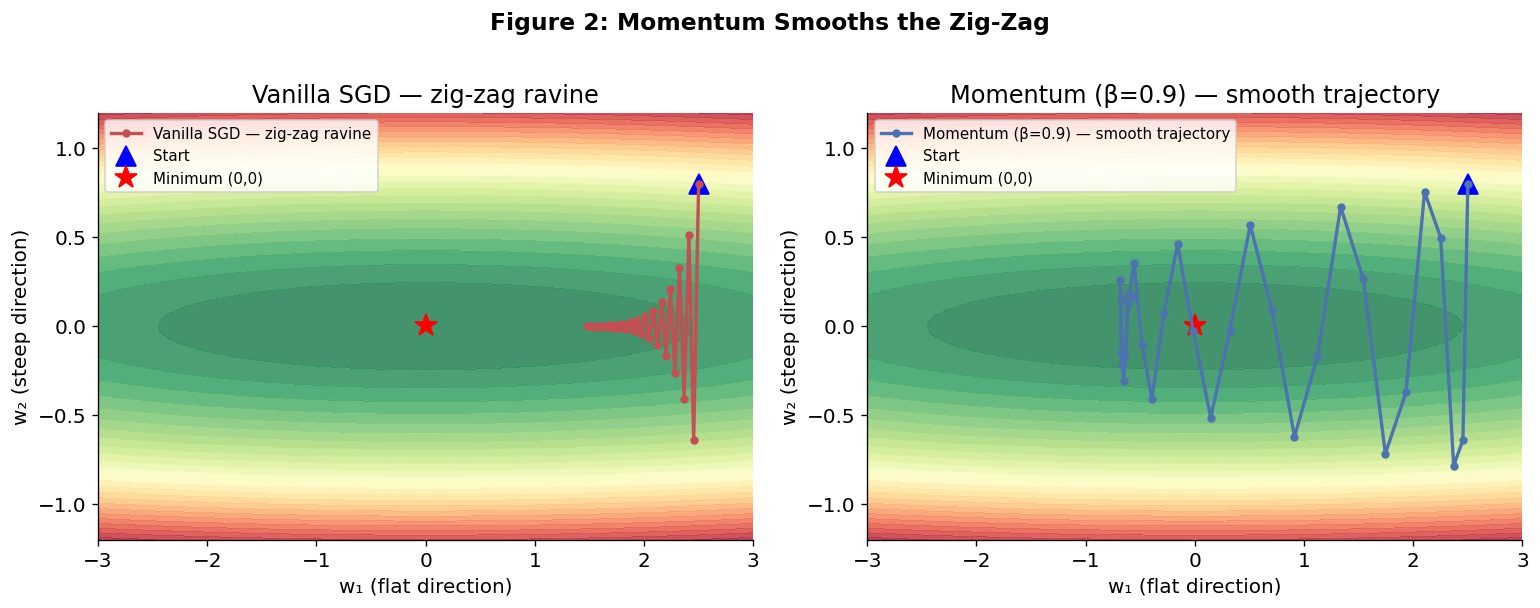

Steps for SGD to reach loss < 0.01: 51
Steps for Momentum to reach loss < 0.01: 15


In [20]:
# Figure 2: Momentum vs SGD — trajectory through a ravine loss surface
np.random.seed(7)

# Ravine loss: steep in y, flat in x — classic momentum test
def ravine_loss(w1, w2): return w1**2 * 0.1 + w2**2 * 10
def ravine_grad(w1, w2): return np.array([0.2*w1, 20*w2])

def run_sgd(lr=0.1, steps=50):
    w = np.array([2.5, 0.8])
    path = [w.copy()]
    for _ in range(steps):
        g = ravine_grad(*w)
        w = w - lr * g
        path.append(w.copy())
    return np.array(path)

def run_momentum(lr=0.1, beta=0.9, steps=50):
    w = np.array([2.5, 0.8])
    v = np.zeros(2)
    path = [w.copy()]
    for _ in range(steps):
        g = ravine_grad(*w)
        v = beta * v + g
        w = w - lr * v
        path.append(w.copy())
    return np.array(path)

path_sgd = run_sgd(lr=0.09)
path_mom = run_momentum(lr=0.09, beta=0.9)

# Loss surface
w1 = np.linspace(-3, 3, 150)
w2 = np.linspace(-1.2, 1.2, 150)
W1, W2 = np.meshgrid(w1, w2)
L = ravine_loss(W1, W2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, path, title, col in [
    (axes[0], path_sgd, 'Vanilla SGD — zig-zag ravine', '#C44E52'),
    (axes[1], path_mom, 'Momentum (β=0.9) — smooth trajectory', '#4C72B0')
]:
    ax.contourf(W1, W2, L, levels=25, cmap='RdYlGn_r', alpha=0.75)
    ax.contour(W1, W2, L, levels=25, colors='white', alpha=0.2, linewidths=0.4)
    pts = path[:30]
    ax.plot(pts[:,0], pts[:,1], 'o-', ms=4, lw=2, color=col, label=title, zorder=5)
    ax.plot(pts[0,0], pts[0,1], 'b^', ms=12, label='Start')
    ax.plot(0, 0, 'r*', ms=14, label='Minimum (0,0)')
    ax.set_xlabel('w₁ (flat direction)'); ax.set_ylabel('w₂ (steep direction)')
    ax.set_title(title); ax.legend(fontsize=9)

plt.suptitle('Figure 2: Momentum Smooths the Zig-Zag', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Show step count to same loss threshold
threshold = 0.01
def steps_to_converge(path):
    for i,(w1,w2) in enumerate(path):
        if ravine_loss(w1,w2) < threshold: return i
    return len(path)

print(f"Steps for SGD to reach loss < {threshold}: {steps_to_converge(path_sgd)}")
print(f"Steps for Momentum to reach loss < {threshold}: {steps_to_converge(path_mom)}")


## 3. AdaGrad — Per-Parameter Learning Rates

Up until this point (Vanilla SGD and Momentum), we have operated under a single assumption: **Every parameter in the neural network deserves the exact same global Learning Rate ($\eta$).** 
AdaGrad (Adaptive Gradient) was the first major optimizer to challenge this assumption.

### Intuition: The "Frequent vs. Rare" Feature Problem

Imagine you are training an NLP model to predict sentiment from movie reviews. 
*   **Frequent Features:** The word "the" appears in almost every single review. Its weights are constantly being updated in every mini-batch. 
*   **Rare Features:** The word "masterpiece" might only appear once in 1,000 reviews. Its weights are almost never touched.

If we use a **Single Global Learning Rate**:
*   If $\eta$ is high enough for the rare word "masterpiece" to learn something quickly, it is far too aggressive for the word "the", causing its weights to violently overshoot and oscillate.
*   If $\eta$ is low enough to keep "the" stable, the weights for "masterpiece" will barely change, and the model will fail to learn its massive importance.

**The AdaGrad Solution:** 
Give every single parameter its own custom, adaptive learning rate. 
*   If a parameter has been updated a lot (frequent features), **decrease** its learning rate to force it to refine fine details.
*   If a parameter has barely been updated (rare features), **keep its learning rate high** so it can take massive steps when it finally gets a chance.

---

### Math: The Historical Accumulator 

To give every parameter its own learning rate, AdaGrad needs a way to "remember" how much each parameter has been updated throughout the entire training process. 

It does this by maintaining a running sum of **Squared Gradients**, which we will call $G_t$. ($G_t$ has the exact same shape as the weight matrix $W$).

**Step 1: Accumulate the Squared Gradients**
$$G_t = G_{t-1} + (\nabla_W\mathcal{L}_t)^2$$

**Step 2: The Adaptive Weight Update**
$$W_t = W_{t-1} - \frac{\eta}{\sqrt{G_t + \epsilon}} \cdot \nabla_W\mathcal{L}_t$$

*   $\eta$: The base global learning rate.
*   $\epsilon$: A tiny number (like $10^{-8}$) added to prevent a divide-by-zero error.
*   **The Magic:** We divide the base learning rate by $\sqrt{G_t}$. 

#### Deep Dive: Unpacking the "Squared Gradient Accumulator" ($G_t$)

What does it mean for $G_t$ to act as an "absolute counter of how much change" a parameter has experienced? 

Why do we square the gradient? Gradients have both a **magnitude** (how steep the slope is) and a **direction** (positive or negative). Imagine a parameter is oscillating wildly, jumping back and forth across a ravine:
*   Step 1 Gradient: `+5.0` (Move left!)
*   Step 2 Gradient: `-5.0` (Move right!)
*   Step 3 Gradient: `+5.0` (Move left!)

If we just kept a normal running sum without squaring them, the sum would be `+5.0`. The optimizer would look at this and say, *"Oh, the sum is small! This parameter must have barely moved at all. Let's give it a massive learning rate!"* This is the exact opposite of what we want.

By squaring the gradient (e.g., $25 + 25 + 25 = 75$), we force every single number to become positive. We stop caring about *which direction* the parameter moved, and only care *that it moved*. 

Think of $G_t$ like the **odometer on a car**. If you drive 50 miles North, and then 50 miles South, your physical position (displacement) hasn't changed. But your odometer knows you drove **100 miles**. Squaring the gradient turns $G_t$ into an odometer for each weight, tracking the total "mileage" of updates it has experienced. 

**Let's see the magic in action:**
*   For a **frequent word** like "the", the gradients are constantly firing. The odometer $G_t$ grows into a massive number. Dividing $\eta$ by a massive number results in a microscopic effective learning rate. The optimizer puts on the brakes.
*   For a **rare word** like "masterpiece", it has never fired. The odometer $G_t$ is near zero. Dividing $\eta$ by a tiny number leaves the learning rate almost completely unshrunk. The optimizer takes a massive, confident step.

---

### The Two Fatal Flaws of AdaGrad

While AdaGrad was a breakthrough for sparse features, it has two major weaknesses that make it unsuitable for deep neural networks.

#### 1. The "Fading Memory" Problem
Look closely at Step 1: $G_t = G_{t-1} + (\nabla_W\mathcal{L}_t)^2$
Because we are adding squared numbers, **$G_t$ can only grow; it can never shrink.** 

As training goes on for hundreds of epochs, $G_t$ eventually becomes astronomically large for *every* parameter in the network. As the denominator in Step 2 grows toward infinity, the effective learning rate $\frac{\eta}{\sqrt{G_t}}$ shrinks closer and closer to **zero**.

**The Result:** After a while, the effective learning rate becomes `0.0000000001`. The network completely stops learning. Training stalls to a halt, long before it has reached the global minimum. 

#### 2. Vulnerability to Saddle Points and Plateaus (No Momentum)
When you look at the fundamental formula for AdaGrad, you'll notice a glaring omission: **There is no velocity ($v_t$) term.** AdaGrad is essentially just Vanilla SGD with a dynamically shrinking learning rate. Because it inherently relies entirely on the *current* gradient ($\nabla_W\mathcal{L}_t$) for direction, it suffers from the exact same topographical traps as Vanilla SGD.

*   **At a Saddle Point:** The current gradient is exactly `0`. It doesn't matter what the effective learning rate is; if you multiply *any* learning rate by `0`, the weight update is `0`. AdaGrad will completely stall.
*   **On a flat Plateau:** The gradient is extremely small. As AdaGrad crawls agonizingly slowly across the plateau, it is taking thousands of tiny steps. Every step adds to the odometer ($G_t$). As $G_t$ grows, the effective learning rate *shrinks*. Not only is the gradient tiny, but AdaGrad actively hits the brakes while driving on a flat road, causing it to stall out even faster than Vanilla SGD would.

*   ✅ **Best Use Case:** Shallow networks dealing with highly sparse data (like standard Bag-of-Words NLP or Recommender Systems).
*   ❌ **Worst Use Case:** Deep Neural Networks and CNNs, where training takes weeks, and landscapes are filled with saddle points.

---

### Master Interview Q&A: AdaGrad

> **Q: What fundamental assumption of Vanilla SGD does AdaGrad attempt to fix, and how does it accomplish this?**
> 
> **A:** Vanilla SGD assumes that every parameter in the network should be updated using the exact same global learning rate. This fails for sparse datasets; frequent features get updated too aggressively and oscillate, while rare features get updated too conservatively and stall. AdaGrad fixes this by dynamically assigning a per-parameter learning rate. It divides the base learning rate by the square root of the accumulated historical gradients for that specific parameter. This automatically shrinks the learning rate for frequent, noisy features ("high mileage" parameters) and maintains a high learning rate for rare, informative features.

> **Q: Explain the mathematical reason why AdaGrad is rarely used for training very deep neural networks (the "Fading Memory" or "Diminishing Learning Rate" problem).**
> 
> **A:** The denominator in the AdaGrad update rule is the square root of the sum of all historical squared gradients ($\sqrt{G_t}$). Because a square is always positive, this accumulator $G_t$ grows monotonically over time; it never drops. During the long training runs required for deep neural networks, this denominator inflates to massive proportions. As a result, the effective learning rate ($\frac{\eta}{\sqrt{G_t}}$) is driven asymptotically toward zero. The network prematurely stops taking meaningful steps, causing training to stall out long before converging on a good minimum. (This flaw is exactly what RMSProp was invented to fix).

> **Q: Does AdaGrad solve the problem of getting stuck at Saddle Points? Why or why not?**
>
> **A:** No, AdaGrad does not solve the Saddle Point problem. AdaGrad adapts the *magnitude* of the update (the learning rate), but it still relies entirely on the *current gradient* for the *direction* of the update. It does not have a momentum or velocity term. When it reaches a saddle point where the current gradient is zero, the parameter update becomes exactly zero, regardless of what the adaptive learning rate is. Consequently, AdaGrad will stall at saddle points exactly like Vanilla SGD.

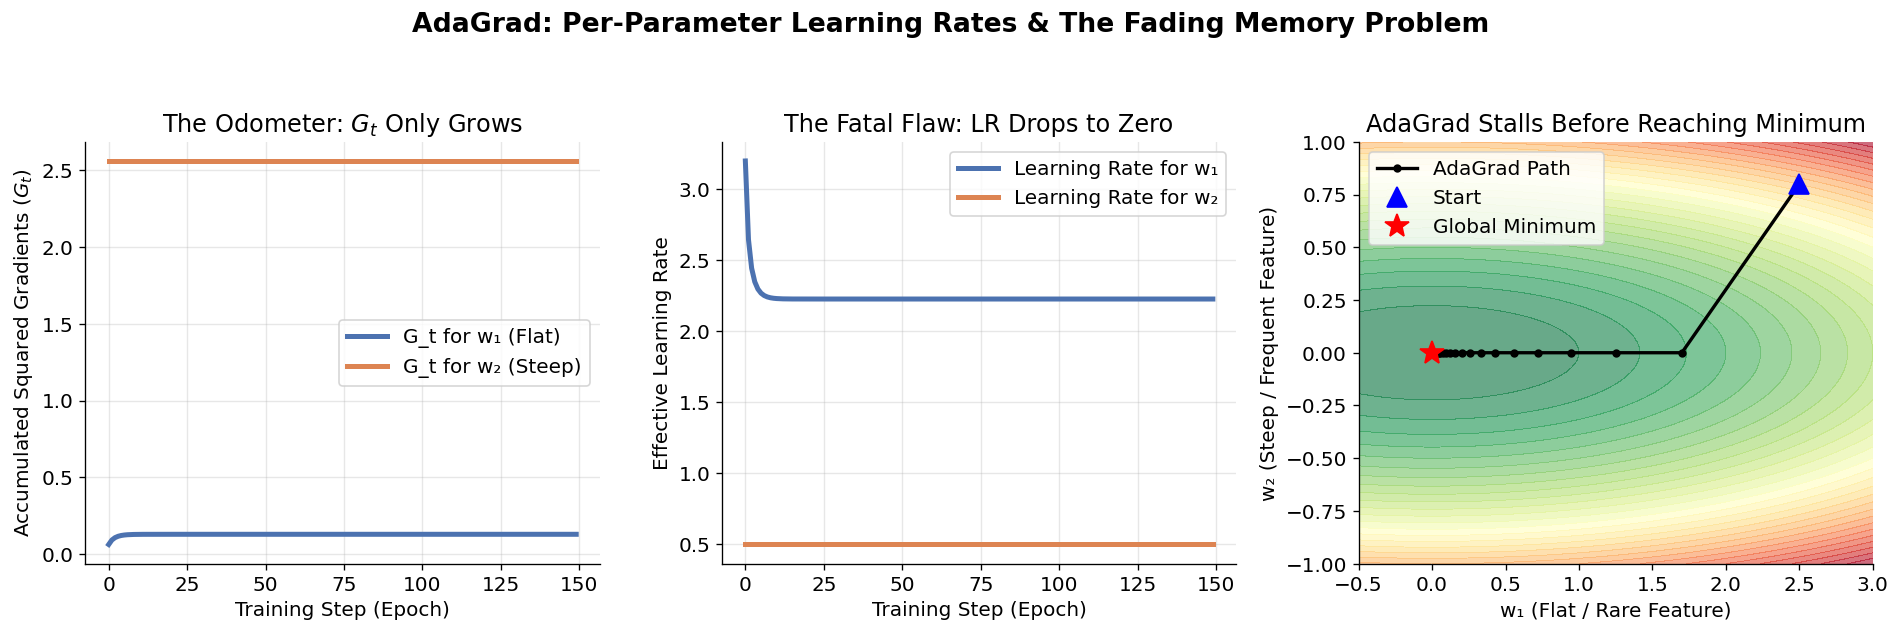

In [27]:
# Figure 3: AdaGrad — The Fading Memory & Odometer Visualization
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Simulate a simple Ravine Loss gradient function
def ravine_grad(w1, w2):
    return np.array([w1 * 0.1, w2 * 2.0]) # w1 is flat (plateau), w2 is steep

def run_adagrad(lr=0.5, steps=150, eps=1e-8):
    w = np.array([2.5, 0.8])
    G = np.zeros(2)
    
    path = [w.copy()]
    eff_lr_hist = []
    G_hist = []
    
    for _ in range(steps):
        g = ravine_grad(w[0], w[1])
        G += g**2  # The Odometer
        
        eff_lr = lr / (np.sqrt(G) + eps)
        w = w - (eff_lr * g)
        
        path.append(w.copy())
        eff_lr_hist.append(eff_lr.copy())
        G_hist.append(G.copy())
        
    return np.array(path), np.array(eff_lr_hist), np.array(G_hist)

path_ada, eff_lrs, G_tracker = run_adagrad(lr=0.8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: The Odometer (G_t accumulating) ──
axes[0].plot(G_tracker[:,0], label='G_t for w₁ (Flat)', color='#4C72B0', lw=3)
axes[0].plot(G_tracker[:,1], label='G_t for w₂ (Steep)', color='#DD8452', lw=3)
axes[0].set_xlabel('Training Step (Epoch)')
axes[0].set_ylabel('Accumulated Squared Gradients ($G_t$)')
axes[0].set_title('The Odometer: $G_t$ Only Grows')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# ── Plot 2: The Fading Memory (Effective LR Drops) ──
axes[1].plot(eff_lrs[:,0], label='Learning Rate for w₁', color='#4C72B0', lw=3)
axes[1].plot(eff_lrs[:,1], label='Learning Rate for w₂', color='#DD8452', lw=3)
axes[1].set_xlabel('Training Step (Epoch)')
axes[1].set_ylabel('Effective Learning Rate')
axes[1].set_title('The Fatal Flaw: LR Drops to Zero')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# ── Plot 3: The Stalling Trajectory ──
# Create background contour
w1_vals = np.linspace(-0.5, 3.0, 100)
w2_vals = np.linspace(-1.0, 1.0, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
L = (W1**2 * 0.05) + (W2**2 * 1.0) # Match ravine_grad

axes[2].contourf(W1, W2, L, levels=30, cmap='RdYlGn_r', alpha=0.6)
axes[2].plot(path_ada[:,0], path_ada[:,1], 'o-', ms=4, lw=2, color='black', label="AdaGrad Path")
axes[2].plot(path_ada[0,0], path_ada[0,1], 'b^', ms=12, label="Start")
axes[2].plot(0, 0, 'r*', ms=15, label="Global Minimum")
axes[2].set_title('AdaGrad Stalls Before Reaching Minimum')
axes[2].set_xlabel('w₁ (Flat / Rare Feature)')
axes[2].set_ylabel('w₂ (Steep / Frequent Feature)')
axes[2].legend()

plt.suptitle('AdaGrad: Per-Parameter Learning Rates & The Fading Memory Problem', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## 4. RMSProp — Fixing AdaGrad's Fading Memory

### Intuition: The "Leaky" Odometer
AdaGrad's biggest flaw is its perfect, infinite memory. Its "odometer" ($G_t$) remembers every single gradient update from the very beginning of training. Even if a parameter essentially stops oscillating and just needs to make steady progress later in training, the massive accumulation of past gradients permanently cripples its learning rate.

**RMSProp (Root Mean Square Propagation)** was originally proposed by Geoffrey Hinton in his Coursera lectures to fix this exact issue. 
Its philosophy is simple: *"Forget the distant past. Only care about recent gradients."*

Instead of a standard running sum that strictly grows toward infinity, RMSProp uses an **Exponentially Weighted Moving Average (EWMA)**. Think of this as a "leaky odometer." It tracks how much the parameter is moving right now, but slowly lets older mileage fade away. If a parameter stops moving violently, the odometer essentially "rolls backward," allowing the learning rate to recover and speed up again.

---

### Math: The Exponential Moving Average (EMA)

Instead of the perpetually growing sum $G_t$, RMSProp introduces $E[g^2]_t$ (the expected value of the squared gradients). 
We also introduce a new hyperparameter, $\rho$ (rho), which controls the "leakiness" or decay rate.

**Step 1: Update the Leaky Odometer**
$$E[g^2]_t = \rho \cdot E[g^2]_{t-1} + (1-\rho) \cdot (\nabla_W\mathcal{L}_t)^2$$

*   If $\rho = 0.9$, this means we keep 90% of our historical average, and add 10% of the brand new squared gradient.

**Step 2: The Adaptive Weight Update**
$$W_t = W_{t-1} - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \cdot \nabla_W\mathcal{L}_t$$

*   *(Notice the update step looks almost identical to AdaGrad, except $G_t$ is replaced by the moving average $E[g^2]_t$)*

#### Why the EMA Fixes the Stalling Problem
In AdaGrad, if a gradient suddenly becomes small (like when entering a flat region), $G_t$ still grows, shrinking the learning rate further. 

In RMSProp, if the current gradient $(\nabla_W\mathcal{L}_t)^2$ becomes very small, the new term being added is tiny. Because the historical term $E[g^2]_{t-1}$ is continually being multiplied by a fraction ($\rho=0.9$), the total accumulator $E[g^2]_t$ will actually **decrease**.
Because the accumulator denominator shrinks, the effective learning rate $\frac{\eta}{\sqrt{E[g^2]_t}}$ **recovers and grows**.

**Result:** RMSProp automatically adapts—it hits the brakes when gradients are huge, but it hits the gas pedal when gradients get small, ensuring the model never stalls completely.

---

### What about Saddle Points?
While RMSProp successfully fixed the "Fading Memory" problem regarding the learning rate, **it did not fix the Saddle Point problem.** 
Just like AdaGrad, RMSProp adapts the *magnitude* of the step but lacks a Velocity/Momentum term for the actual parameter update step. It still relies entirely on the *current* gradient for direction. If it hits a saddle point where the current gradient is exactly `0`, the update is `0`, and the model stalls. 
*(This final puzzle piece paves the way for the invention of Adam).*

*   ✅ **Best Use Case:** Recurrent Neural Networks (RNNs) and environments where the loss landscape changes constantly (non-stationary objectives). It remains one of the best optimizers available.

---

### Master Interview Q&A: RMSProp

> **Q: What fatal flaw of AdaGrad does RMSProp fix, and how does it accomplish this mathematically?**
> 
> **A:** AdaGrad suffers from the "fading memory" problem: its accumulator of squared gradients grows monotonically, driving the effective learning rate to zero and causing training to stall in deep networks. RMSProp fixes this by replacing the simple geometric sum with an Exponentially Weighted Moving Average (EWMA) using a decay parameter $\rho$. This applies an exponential discount to older gradients, allowing the accumulator to actually shrink if recent gradients become small. This prevents the effective learning rate from dropping to zero and allows the network to continue learning indefinitely.

> **Q: In RMSProp, what does the $\rho$ (rho/decay) parameter control, and what are the effects of tuning it?**
> 
> **A:** The $\rho$ hyperparameter dictates the "memory length" or decay rate of the moving average. A standard value like $\rho=0.9$ means the current moving average is composed of 90% past history and 10% the newest squared gradient. 
> *   A **higher $\rho$** (e.g., `0.99`) creates a longer memory, meaning the learning rate adapts smoothly and resists sudden, single-step spikes in gradient noise.
> *   A **lower $\rho$** (e.g., `0.7`) creates a short memory, making the optimizer highly reactive to sudden, recent changes in the loss landscape.

> **Q: Does RMSProp use momentum to escape saddle points?**
>
> **A:** No. Standard RMSProp only applies a moving average to the *squared gradients* in order to scale the learning rate. It does NOT apply a moving average to the gradients themselves (velocity) for the actual parameter update step. Therefore, just like Vanilla SGD and AdaGrad, it relies purely on the current gradient for direction and can stall at saddle points where the gradient is zero.


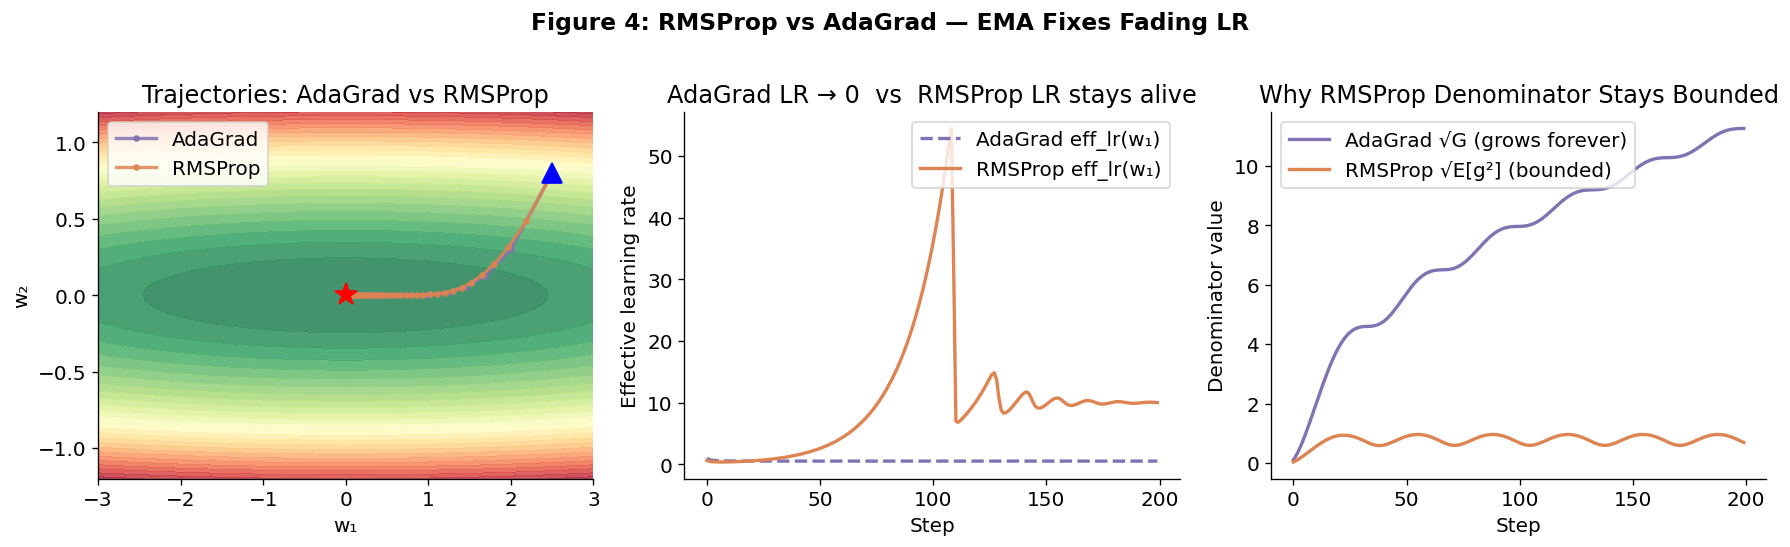

In [22]:
# Figure 4: RMSProp — effective LR stays alive vs AdaGrad
np.random.seed(0)

def run_rmsprop(lr=0.1, rho=0.9, steps=200, eps=1e-8):
    w = np.array([2.5, 0.8])
    E_g2 = np.zeros(2)
    path, eff_lr_hist = [w.copy()], []
    for _ in range(steps):
        g = ravine_grad(*w)
        E_g2 = rho * E_g2 + (1 - rho) * g**2
        eff_lr = lr / (np.sqrt(E_g2) + eps)
        w = w - eff_lr * g
        path.append(w.copy())
        eff_lr_hist.append(eff_lr.copy())
    return np.array(path), np.array(eff_lr_hist)

path_rms, eff_lrs_rms = run_rmsprop(lr=0.1)
_, eff_lrs_ada = run_adagrad(lr=0.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Plot 1: Trajectory comparison ──
axes[0].contourf(W1, W2, L, levels=25, cmap='RdYlGn_r', alpha=0.75)
axes[0].contour(W1, W2, L, levels=25, colors='white', alpha=0.2, linewidths=0.4)
for path, col, lbl in [(path_ada,'#8172B3','AdaGrad'),(path_rms,'#DD8452','RMSProp')]:
    axes[0].plot(path[:50,0], path[:50,1], 'o-', ms=3, lw=2, color=col, label=lbl, alpha=0.85)
axes[0].plot(path_ada[0,0], path_ada[0,1], 'b^', ms=12)
axes[0].plot(0, 0, 'r*', ms=14)
axes[0].set_title('Trajectories: AdaGrad vs RMSProp')
axes[0].set_xlabel('w₁'); axes[0].set_ylabel('w₂'); axes[0].legend()

# ── Plot 2: Effective LR comparison ──
axes[1].plot(eff_lrs_ada[:,0], label='AdaGrad eff_lr(w₁)', color='#8172B3', lw=2, ls='--')
axes[1].plot(eff_lrs_rms[:,0], label='RMSProp eff_lr(w₁)', color='#DD8452', lw=2)
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Effective learning rate')
axes[1].set_title('AdaGrad LR → 0  vs  RMSProp LR stays alive')
axes[1].legend()

# ── Plot 3: EMA of g² vs cumsum of g² ──
g_seq = np.abs(np.sin(np.linspace(0, 6*np.pi, 200))) + 0.1
adagrad_denom = np.cumsum(g_seq**2)
rms_denom = np.zeros(200)
v = 0
for i,g in enumerate(g_seq):
    v = 0.9*v + 0.1*g**2
    rms_denom[i] = v
axes[2].plot(np.sqrt(adagrad_denom), label='AdaGrad √G (grows forever)', color='#8172B3', lw=2)
axes[2].plot(np.sqrt(rms_denom), label='RMSProp √E[g²] (bounded)', color='#DD8452', lw=2)
axes[2].set_xlabel('Step'); axes[2].set_ylabel('Denominator value')
axes[2].set_title('Why RMSProp Denominator Stays Bounded')
axes[2].legend()

plt.suptitle('Figure 4: RMSProp vs AdaGrad — EMA Fixes Fading LR', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Adam — Adaptive Moment Estimation (The Industry Default)

Up to this point, we have seen two distinct branches of evolution in optimizers:
1.  **Momentum:** Added "Velocity" to solve the problem of stalling at **Saddle Points** and oscillating in Ravines. (But kept a single global learning rate).
2.  **RMSProp:** Added an "Exponential Moving Average of Squared Gradients" to solve the problem of creating **Adaptive Per-Parameter Learning Rates** without stalling on Plateaus. (But forgot to include Velocity, so it still stalls at Saddle points).

**Adam (Adaptive Moment Estimation)**, published in 2014, is the ultimate culmination of both branches. It simply takes **Momentum** and smashes it together with **RMSProp**, with one crucial mathematical fix added on top: **Bias Correction**.

### Intuition: The Smart, Heavy Bowling Ball
the easiest way to explain Adam is to say it simply combines the best parts of **Momentum** and **RMSProp**.

At every step, Adam asks two simple questions:

**1. Question 1: Which way have I been going? (From Momentum)** Adam remembers its past directions. If the gradients keep pointing the exact same way over time, Adam builds up speed. This helps the optimizer cross flat plateaus and escape saddle points without getting stuck.
Question 

**2: How "noisy" is this exact parameter? (From RMSProp)** Adam tracks how wildly each individual parameter is jumping around. If a parameter is zig-zagging back and forth, Adam automatically hits the brakes and shrinks its learning rate. If a parameter is moving smoothly, Adam keeps the learning rate high.


**Adam's internal logic:** "I will look at my past momentum to decide my direction. Then, I will look at how noisy each parameter is. If a parameter's path is smooth and consistent, I will take a big, confident step. If a parameter's path is noisy and chaotic, I will take a small, careful step."

---

### The Math: Tracking the Two Moments

Adam maintains two separate Exponentially Weighted Moving Averages (EWMA) for every parameter. In statistics, these are referred to as "Moments".

*   $\eta$ = Base Learning Rate (Default: `0.001`)
*   $\beta_1$ = Decay rate for the 1st Moment (Default: `0.9`)
*   $\beta_2$ = Decay rate for the 2nd Moment (Default: `0.999`)

**1. The First Moment (Velocity / Mean):** 
This is exactly the same as Standard Momentum. It tracks the EMA of the gradients themselves.
$$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot \nabla_W\mathcal{L}_t$$

**2. The Second Moment (Variance / RMSProp):** 
This is exactly the same as RMSProp. It tracks the EMA of the *squared* gradients.
$$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot (\nabla_W\mathcal{L}_t)^2$$

---

### The Fix: Bias Correction (The "Cold Start" Problem)

Because both $m_t$ and $v_t$ are initialized as matrices of pure zeros ($m_0=0, v_0=0$), Adam suffers from a "Cold Start" problem. 

Let's look at the very first training step ($t=1$) for the 1st Moment:
$$m_1 = (0.9 \cdot 0) + (0.1 \cdot g_1) = 0.1 \cdot g_1$$

The true gradient was $g_1$, but because the moving average was overwhelmingly biased by the initial zero, the calculated momentum $m_1$ is **10x smaller** than it should be! If we didn't fix this, Adam would take microscopic steps at the beginning of training, wasting valuable epochs.

**The Bias Correction Step:**
To fix this, we divide the moments by a decay factor that shrinks over time: $(1 - \beta^t)$.
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

*   **At Step 1:** $\hat{m}_1 = \frac{0.1 \cdot g_1}{1 - 0.9^1} = \frac{0.1 \cdot g_1}{0.1} = g_1$. (Perfectly corrected!)
*   **At Step 1000:** $1 - 0.9^{1000} \approx 1$. (The correction factor fades away entirely once the optimizer is fully "warmed up").

---

### The Final Update Rule (Signal-to-Noise Ratio)

Finally, we combine the bias-corrected moments to update the weights:
$$W_t = W_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \cdot \hat{m}_t$$

**Intuition for the Effective Step Size:** 
You can think of Adam's update step as a **Signal-to-Noise Ratio (SNR)**. 
$$\text{Effective Step} \approx \eta \cdot \frac{\text{Signal (Mean)}}{\text{Noise (Variance)}}$$
*   **High Signal / Low Noise:** If a gradient is consistently positive, the Mean ($\hat{m}$) is high, and the Variance ($\hat{v}$) equals the square of the mean. The terms cancel out, and Adam takes a massive step roughly equal to the defined learning rate $\eta$.
*   **Low Signal / High Noise:** If a gradient is wildly oscillating (+, -, +, -), the Mean ($\hat{m}$) cancels out to `0`, but the Variance ($\hat{v}$) becomes huge. Adam divides `0` by a huge number, resulting in a step size of `0`. It refuses to move in noisy directions.

---

### Master Interview Q&A: Adam

> **Q: Does Adam suffer from the "Overshooting" problem, similar to Standard Momentum?**
> 
> **A:** Yes, but to a significantly lesser degree than Standard Momentum because it has a built-in "braking" mechanism.
> 
> *   **Why it can overshoot:** Adam uses Standard Momentum for its first moment. Because it builds up speed when taking multiple steps in the same direction, it can accumulate too much momentum and accidentally step right past the lowest point of the loss landscape (the minimum).
> *   **How Adam catches the mistake:** When the optimizer steps past the lowest point, it essentially starts walking uphill, causing the gradient to instantly reverse direction (e.g., flipping from `+10` to `-10`). 
> 
> Mathematically, Adam calculates its step size by dividing the Velocity (the 1st moment) by the Variance/Bumpiness (the 2nd moment). When the gradient suddenly flips direction:
> 1. The **Velocity** averages the positive and negative directions together (`+10` and `-10`), canceling out and dropping toward `0`.
> 2. The **Variance** (which squares the gradients) stays huge because `(+10)^2` and `(-10)^2` are both `100`.
> 
> By dividing a shrinking Velocity (near `0`) by a massive Variance (`100`), the calculated step size immediately shrinks toward zero. The very second Adam overshoots and the gradient flips, the math automatically hits the brakes to prevent the optimizer from running out of control up the incorrect side of the curve.

> **Q: What are the two "Moments" that Adam tracks, and what physical properties do they represent conceptually?**
> 
> **A:** Adam tracks two distinct Exponentially Weighted Moving Averages (EWMAs). 
> The **1st Moment ($m_t$)** tracks the gradients themselves. Conceptually, this represents the **Velocity** or "Momentum" of the optimizer, allowing it to build inertia in consistent directions and plow through saddle points. 
> The **2nd Moment ($v_t$)** tracks the *squared* gradients. Conceptually, this represents the **Variance** or "Bumpiness" of the gradients for each individual parameter, acting exactly like RMSProp. 
> Adam combines them by dividing the Velocity by the square root of the Variance to formulate an adaptive, per-parameter momentum update.

> **Q: Why is "Bias Correction" mathematically necessary in the Adam optimizer?**
> 
> **A:** Because both moment accumulators ($m_t$ and $v_t$) are initialized to zero at the start of training, the early exponential moving averages are heavily biased toward zero. For example, at $t=1$, with $\beta_1=0.9$, the calculated 1st moment is only 10% of the true gradient. If left uncorrected, the optimizer would take artificially tiny steps during the first few epochs (the "Cold Start" problem). By dividing the moments by $(1 - \beta^t)$, Adam mathematically scales these early estimates back up to their true, unbiased magnitudes. As $t$ approaches infinity, $(1 - \beta^t)$ approaches $1$, naturally phasing out the correction term.

> **Q: In state-of-the-art literature, why is Vanilla SGD with Momentum sometimes preferred over Adam for training massive Computer Vision models (like ResNet), even though Adam converges faster?**
> 
> **A:** It boils down to **Generalization vs. Speed**. Adam is phenomenal at finding an acceptable local minimum incredibly fast, and it requires very little hyperparameter tuning. However, Adam's adaptive learning rates tend to steer the model into "sharp" minima—valleys that are deep but very narrow in the loss landscape. Sharp minima often generalize poorly to unseen validation data.
> Conversely, Vanilla SGD with Momentum navigates the landscape much more chaotically. This inherent noise prevents it from settling into sharp minima, forcing it to find "flat", broad basins instead. While SGD requires exhaustive tuning of Learning Rate Schedules and takes much longer to converge, those flat basins routinely yield a 1-2% higher final accuracy on the test set.

> **Q: Does Adam's effective step size ever exceed the base learning rate ($\eta$) you set, and what is its theoretical maximum bound?**
> 
> **A:** For the vast majority of training, Adam acts conservatively and strictly limits its step size to be **less than or equal to** ($\le$) your base learning rate ($\eta$). However, due to its internal math, it possesses a strict "speed limit" allowing it to theoretically spike up to about 31.6 times your learning rate under very specific conditions.
> 
> Here is the intuitive breakdown of how this happens:
> 
> Adam computes its step size using the Signal-to-Noise Ratio: `Base LR * (Velocity / Bumpiness)`.
> 
> *   **Normal Training (Ratio $\le 1$):** If the loss landscape is perfectly smooth, the Velocity and Bumpiness match. The ratio `Velocity / Bumpiness` cancels out to exactly `1.0`. Therefore, Adam's step size is exactly equal to your base $\eta$. If the landscape becomes noisy, the Velocity drops, the ratio drops below 1.0, and the step size shrinks.
> 
> *   **The Rare Spike (Ratio $> 1$):** The only time the ratio can exceed `1.0` is for **extremely sparse features**—when a parameter receives a massive gradient update for one single step, but receives a gradient of `0` for all other steps. Because of how the Exponential Moving Averages decay, the absolute mathematical limit this ratio can hit before the math breaks down is bounded by the formula: $1 / \sqrt{1 - \beta_2}$.
> 
> *   **The Absolute Speed Limit:** Since the $\beta_2$ hyperparameter defaults to `0.999`, plugging it into the formula yields $1 / \sqrt{1 - 0.999} \approx 31.6$.
> 
> **Summary:** You can think of your base learning rate $\eta$ as the "Target Cruising Speed." Adam spends 99% of training driving at or below this cruising speed. But if an extremely rare, sparse feature suddenly appears, Adam allows itself to temporarily hit the gas, governed by a strict, theoretically proven maximum speed limit of $\approx 31.6 \times \eta$.


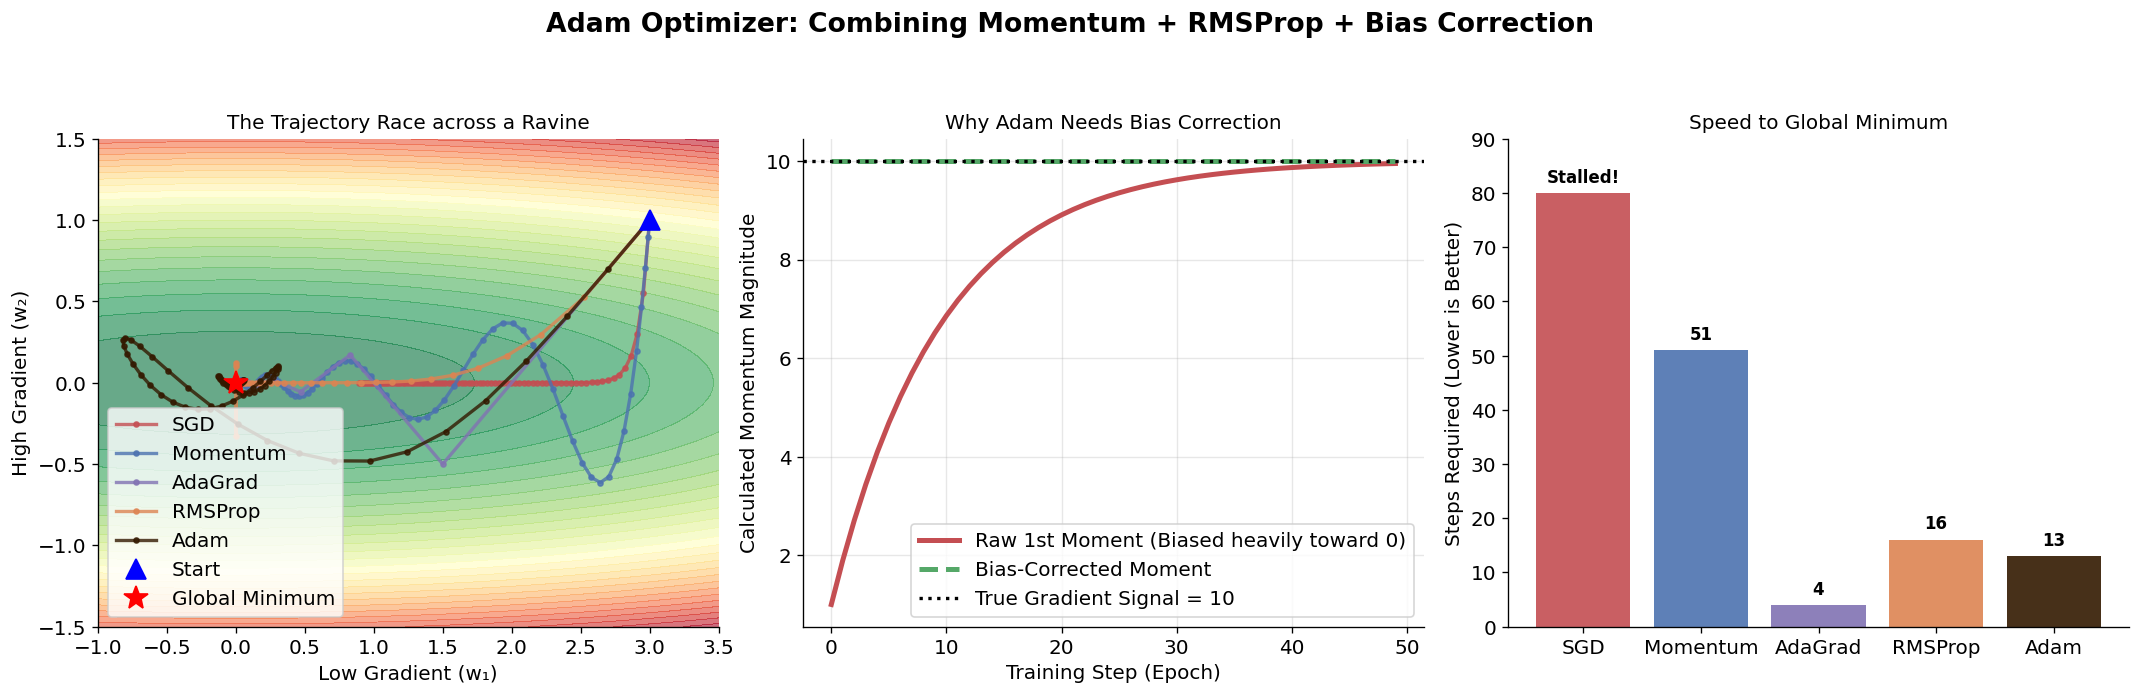

In [32]:
# Figure 5: The Ultimate Showdown - Adam vs The World
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- 1. Define the Ravine Landscape & Gradient ---
def ravine_loss(w1, w2):
    return (w1**2 * 0.05) + (w2**2 * 1.5)

def ravine_grad(w1, w2):
    return np.array([w1 * 0.1, w2 * 3.0])

# Background Contour Grid
w1_vals, w2_vals = np.linspace(-1, 3.5, 100), np.linspace(-1.5, 1.5, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
L = ravine_loss(W1, W2)

# --- 2. Optimizer Simulators ---
def run_optim(name, lr, steps=80):
    w = np.array([3.0, 1.0]) # Start point
    path = [w.copy()]
    
    # Trackers
    v_mom, G_ada, E_rms = np.zeros(2), np.zeros(2), np.zeros(2)
    m_adam, v_adam = np.zeros(2), np.zeros(2)
    
    for t in range(1, steps + 1):
        g = ravine_grad(*w)
        
        if name == 'SGD':
            w -= lr * g
        elif name == 'Momentum':
            v_mom = 0.9 * v_mom + 0.1 * g
            w -= lr * v_mom
        elif name == 'AdaGrad':
            G_ada += g**2
            w -= (lr / (np.sqrt(G_ada) + 1e-8)) * g
        elif name == 'RMSProp':
            E_rms = 0.9 * E_rms + 0.1 * g**2
            w -= (lr / (np.sqrt(E_rms) + 1e-8)) * g
        elif name == 'Adam':
            m_adam = 0.9 * m_adam + 0.1 * g
            v_adam = 0.999 * v_adam + 0.001 * g**2
            m_hat = m_adam / (1 - 0.9**t)
            v_hat = v_adam / (1 - 0.999**t)
            w -= (lr / (np.sqrt(v_hat) + 1e-8)) * m_hat
            
        path.append(w.copy())
    return np.array(path)

# Run simulations
# Note: Learning rates are tuned differently because adaptive optimizers need higher base LRs
paths = {
    'SGD':      run_optim('SGD', lr=0.15),
    'Momentum': run_optim('Momentum', lr=0.35),
    'AdaGrad':  run_optim('AdaGrad', lr=1.5),
    'RMSProp':  run_optim('RMSProp', lr=0.15),
    'Adam':     run_optim('Adam', lr=0.3)
}

# --- 3. Plotting the 3-Panel Graph ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
colors = {'SGD': '#C44E52', 'Momentum': '#4C72B0', 'AdaGrad': '#8172B3', 'RMSProp': '#DD8452', 'Adam': '#331900'}

# [Plot 1]: The Trajectory Race
axes[0].contourf(W1, W2, L, levels=30, cmap='RdYlGn_r', alpha=0.6)
for name, path in paths.items():
    axes[0].plot(path[:,0], path[:,1], '.-', ms=6, lw=2, color=colors[name], label=name, alpha=0.8)

axes[0].plot(3.0, 1.0, 'b^', ms=12, label="Start")
axes[0].plot(0, 0, 'r*', ms=15, label="Global Minimum")
axes[0].set_title('The Trajectory Race across a Ravine', fontsize=12)
axes[0].set_xlabel('Low Gradient (w₁)'); axes[0].set_ylabel('High Gradient (w₂)')
axes[0].legend(loc='lower left')

# [Plot 2]: Adam's Bias Correction (Cold Start Fix)
b1 = 0.9
g_seq = np.ones(50) * 10  # Suppose the true gradient is consistently 10
m_raw, m_corrected = [], []
m = 0.0

for t in range(1, 51):
    m = b1*m + (1-b1)*g_seq[t-1]
    m_raw.append(m)
    m_corrected.append(m / (1 - b1**t))

axes[1].plot(m_raw, label='Raw 1st Moment (Biased heavily toward 0)', color='#C44E52', lw=3)
axes[1].plot(m_corrected, label='Bias-Corrected Moment', color='#55A868', lw=3, linestyle='--')
axes[1].axhline(10.0, color='black', ls=':', lw=2, label='True Gradient Signal = 10')
axes[1].set_xlabel('Training Step (Epoch)'); axes[1].set_ylabel('Calculated Momentum Magnitude')
axes[1].set_title('Why Adam Needs Bias Correction', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# [Plot 3]: Steps to Convergence Bar Chart
threshold = 0.01
conv_steps = {}

for name, path in paths.items():
    steps = 80
    for i, (w1, w2) in enumerate(path):
        if ravine_loss(w1, w2) < threshold: 
            steps = i
            break
    conv_steps[name] = steps

bars = axes[2].bar(conv_steps.keys(), conv_steps.values(), color=[colors[n] for n in conv_steps.keys()], alpha=0.9)
axes[2].set_ylabel('Steps Required (Lower is Better)')
axes[2].set_title('Speed to Global Minimum', fontsize=12)
axes[2].set_ylim(0, 90)

# Add text labels on top of bars
for bar, name in zip(bars, conv_steps.keys()):
    val = conv_steps[name]
    label = str(val) if val < 80 else "Stalled!"
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 label, ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Adam Optimizer: Combining Momentum + RMSProp + Bias Correction', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## 6. AdamW — Fixing Weight Decay for Transformers

While Adam is fantastic, researchers noticed a strange phenomenon: when training state-of-the-art models (like Transformers or large CNNs), Vanilla **SGD + Momentum** regularly achieved better test-set accuracy than Adam. 

The secret culprit? **Weight Decay (L2 Regularization).** The way Adam applied Weight Decay was mathematically broken. 

**AdamW (Adam with decoupled Weight decay)** was invented to fix this specific mathematical bug. Today, AdamW is the absolute gold standard for training LLMs (GPT, LLaMA, BERT).

---

### Understanding the Bug: L2 Regularization vs. Weight Decay

The goal of Weight Decay is simple: force the network's weights to stay small so the model doesn't overfit. 
Historically, there were two ways to do this:
1.  **L2 Regularization:** Add a penalty to the *Gradient* (telling the optimizer the slope is steeper than it actually is).
2.  **Weight Decay:** Subtract a tiny percentage from the *Weight* directly at the end of every step.

**In Vanilla SGD, these two methods are mathematically identical.** 
Because SGD uses a single global learning rate, adding a penalty to the gradient results in the exact same weight update as subtracting a penalty from the weight itself. Because they were identical, deep learning frameworks (like PyTorch) just combined them into one parameter called `weight_decay`. 

**The Adam Bug:**
Adam does *not* use a single global learning rate; it has an adaptive, per-parameter learning rate based on the Variance (the 2nd moment). 
When PyTorch applied "L2 Regularization" to Adam, it added the penalty to the gradient. But then, Adam's math stepped in and **divided that gradient by the Variance.**
$$W_t = W_{t-1} - \frac{\eta}{\text{Variance}} \times (G_{true} + G_{penalty})$$

**The Result:** If a parameter had a huge variance (bumpy history), Adam would shrink its learning rate. But because the penalty was inside the gradient parenthesis, **Adam accidentally shrank the regularization penalty too!** Parameters with high variance received almost zero regularization, completely breaking the intended effect of Weight Decay.

---

### The AdamW Fix: Decoupling

The fix proposed in the AdamW paper is surprisingly simple: **Stop adding the penalty to the gradient.**
Instead, apply the Weight Decay directly to the weights *after* Adam has calculated all of its adaptive learning rate math. 

$$W_t = W_{t-1} - \left(\frac{\eta}{\text{Variance}} \times G_{true}\right) - (\eta \times \lambda \times W_{t-1})$$

*(Notice that the $- \eta \lambda W$ term is completely outside the adaptive variance fraction).*

By "decoupling" Weight Decay from the gradient calculation, AdamW guarantees that every single parameter in the network is decayed by the exact same percentage ($\lambda$), regardless of how bumpy or sparse its gradient history is. 

### In Practice
If you use PyTorch, you should almost never use `torch.optim.Adam` if you are using weight decay. Always use `AdamW`.

```python
# ❌ BAD: Adam treats weight_decay as L2 Regularization (Broken in Adam)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ✅ GOOD: AdamW explicitly decouples the weight decay (The Industry Standard)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
```

---

### Master Interview Q&A: AdamW

> **Q: What is the defining difference between Adam and AdamW, and why was AdamW created?**
> 
> **A:** AdamW was created to fix a mathematical flaw in how Adam handles L2 Regularization. In standard SGD, L2 Regularization (modifying the gradient) and true Weight Decay (modifying the weight directly) are mathematically equivalent. However, Adam divides all gradients by a parameter-specific historical variance. In standard Adam, the L2 penalty is added to the gradient *before* this division takes place. This means the regularization penalty is unevenly scaled down for parameters with high variance, breaking the intended regularization effect. 
> AdamW fixes this by "decoupling" the weight decay. It calculates the standard Adam update using the pure gradients, and then applies a uniform decay directly to the weights afterward. 

> **Q: Why is AdamW universally preferred over standard Adam for training Transformers (like BERT or GPT)?**
> 
> **A:** Transformers are massive, heavily over-parameterized models that are exceptionally prone to overfitting. Consistent, reliable weight decay is absolutely critical to force these models to generalize well rather than just memorizing the training data. Standard Adam fails to apply this regularization evenly, often leading to worse validation performance. The decoupled weight decay in AdamW ensures all parameters are forced to stay small, which is why the original BERT paper and all modern LLMs rely exclusively on AdamW.

> **Q: What constitutes a good starting value for the `weight_decay` hyperparameter when using AdamW?**
> 
> **A:** For massive models like Transformers, `0.01` to `0.1` is the standard starting baseline. For deep Computer Vision models like ResNets, you can often start smaller, around `1e-4` to `1e-2`. Outside of the Learning Rate itself, finding the correct Weight Decay is arguably the most impactful hyperparameter you can tune to bridge the generalization gap.


### Deep Dive: L2 Regularization vs. True Weight Decay

The goal of regularization is simple: force the network's weights to stay small so the model doesn't overfit. Historically, there were two distinct ways to think about this:

#### 1. The "True Weight Decay" Method
The original concept of Weight Decay was simply: *"After the optimizer finishes taking its normal step, artificially shrink the weight by a tiny percentage so it doesn't get too big."*

Mathematically, it looks like this:
$$W_{new} = W_{old} - (\eta \times Gradient) - (\lambda \times W_{old})$$
*(where $\lambda$ is a tiny number like 0.01)*

**Intuition:** "Calculate the new weight by taking the old weight, taking a normal step downhill, and then subtracting 1% of the weight to artificially shrink it."

#### 2. The "L2 Regularization" Method
L2 Regularization approaches the problem differently. Instead of shrinking the weight at the end, it alters the *Loss Function* before the step even happens. It says: *"Let's add a penalty to the Loss Function based on how big the weights are. If the weights get big, the Loss goes up."*

$$Loss_{new} = Loss_{original} + \left( \frac{\lambda}{2} \times W_{old}^2 \right)$$

When the optimizer calculates the Gradient (the derivative) of this new Loss Function, the math rule for derivatives brings that "squared" term down:
$$Gradient_{new} = Gradient_{original} + (\lambda \times W_{old})$$

Now, let's plug this "penalized" gradient into the standard Vanilla SGD formula:
$$W_{new} = W_{old} - \eta \times (Gradient_{new})$$
$$W_{new} = W_{old} - \eta \times [Gradient_{original} + (\lambda \times W_{old})]$$

If we distribute the Learning Rate ($\eta$) into the brackets, we get:
$$W_{new} = W_{old} - (\eta \times Gradient_{original}) - (\eta \times \lambda \times W_{old})$$

---

#### The Revelation: They Are Exactly The Same (in SGD)

Look at the final equation for L2 Regularization:
$$W_{new} = W_{old} - (\eta \times Gradient_{original}) - (\eta \times \lambda \times W_{old})$$

Look at the original equation for True Weight Decay:
$$W_{new} = W_{old} - (\eta \times Gradient) - (\lambda \times W_{old})$$

**They are mathematically identical.** 
The only difference is that in L2 Regularization, the decay rate ($\lambda$) gets multiplied by the learning rate ($\eta$). Because they result in the exact same mathematical operation (shrinking the weight linearly), the authors of deep learning frameworks (like PyTorch) just combined them into a single parameter called `weight_decay`.

---

#### Why This Breaks in Adam

This convenient trick—treating L2 regularization and Weight Decay as the same thing—only works if you have a **single, global learning rate** ($\eta$).

Adam does not use a global learning rate; it creates a custom fraction for every single parameter ($\frac{\eta}{\text{Variance}}$). When Adam distributes that fraction into the brackets, the Penalty term gets divided by the Variance too!

$$W_{new} = W_{old} - \left(\frac{\eta}{\text{Variance}} \times Gradient\right) - \left(\frac{\eta \times \lambda}{\text{Variance}} \times W_{old}\right)$$

**The Result:** The amount of weight decay now changes based on how noisy the parameter is! If a parameter is noisy (huge variance), the math divides the penalty by a massive number, resulting in almost **zero weight decay**. 

That is exactly why **AdamW** was invented: to pull that penalty **OUT** of the brackets, preventing it from being divided by Adam's variance.


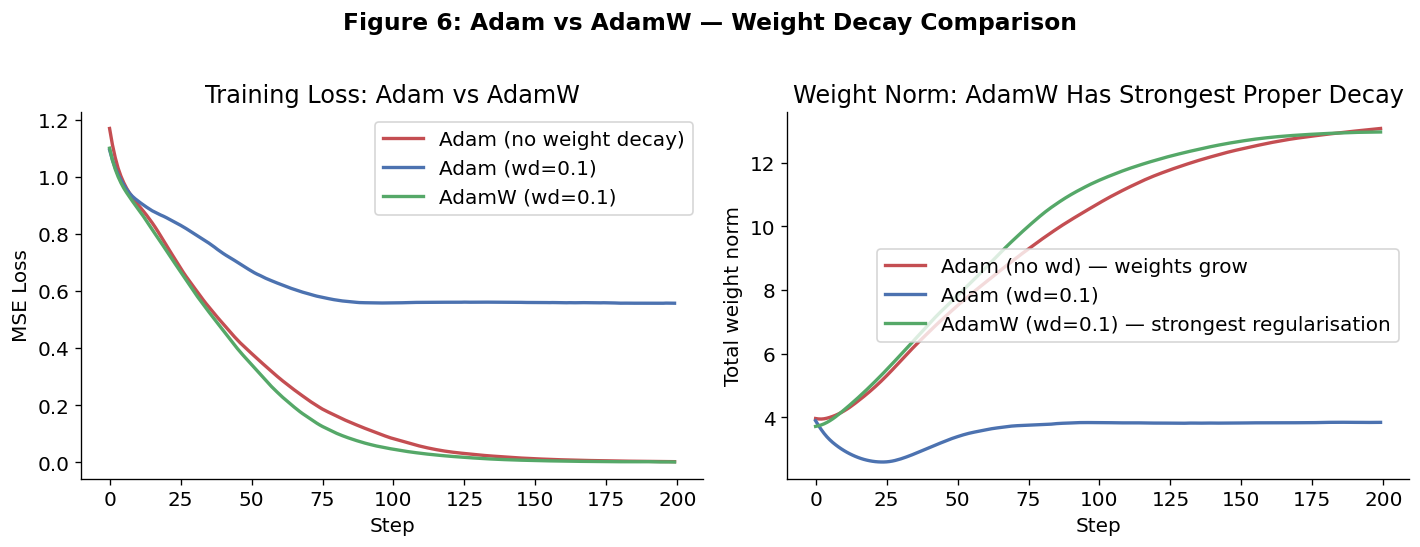

PyTorch API:
  torch.optim.Adam(model.parameters(),  lr=1e-3, weight_decay=1e-4)   # L2 in gradient (less correct)
  torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)   # True weight decay (preferred)

For transformers (BERT, GPT, ViT): AdamW is the standard ✓


In [24]:
# AdamW vs Adam — weight decay effect demonstration
import torch
import torch.nn as nn

torch.manual_seed(42)

# Simple model: 2-layer MLP on synthetic task
def make_model(): return nn.Sequential(nn.Linear(10,20), nn.ReLU(), nn.Linear(20,1))
def make_data(N=100):
    X = torch.randn(N, 10)
    y = torch.randn(N, 1)
    return X, y

X, y = make_data()

def train_optimizer(opt_class, opt_kwargs, steps=200):
    model = make_model()
    optimizer = opt_class(model.parameters(), **opt_kwargs)
    losses, weight_norms = [], []
    for _ in range(steps):
        optimizer.zero_grad()
        loss = nn.MSELoss()(model(X), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        wn = sum(p.norm().item() for p in model.parameters())
        weight_norms.append(wn)
    return losses, weight_norms

loss_adam,  wn_adam  = train_optimizer(torch.optim.Adam,  {'lr':1e-2, 'weight_decay':0.1})
loss_adamw, wn_adamw = train_optimizer(torch.optim.AdamW, {'lr':1e-2, 'weight_decay':0.1})
loss_noreg, wn_noreg = train_optimizer(torch.optim.Adam,  {'lr':1e-2, 'weight_decay':0.0})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(loss_noreg, label='Adam (no weight decay)', color='#C44E52', lw=2)
axes[0].plot(loss_adam,  label='Adam (wd=0.1)',           color='#4C72B0', lw=2)
axes[0].plot(loss_adamw, label='AdamW (wd=0.1)',          color='#55A868', lw=2)
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss: Adam vs AdamW'); axes[0].legend()

axes[1].plot(wn_noreg, label='Adam (no wd) — weights grow', color='#C44E52', lw=2)
axes[1].plot(wn_adam,  label='Adam (wd=0.1)',                color='#4C72B0', lw=2)
axes[1].plot(wn_adamw, label='AdamW (wd=0.1) — strongest regularisation', color='#55A868', lw=2)
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Total weight norm')
axes[1].set_title('Weight Norm: AdamW Has Strongest Proper Decay'); axes[1].legend()

plt.suptitle('Figure 6: Adam vs AdamW — Weight Decay Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Show PyTorch API comparison
print("PyTorch API:")
print("  torch.optim.Adam(model.parameters(),  lr=1e-3, weight_decay=1e-4)   # L2 in gradient (less correct)")
print("  torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)   # True weight decay (preferred)")
print()
print("For transformers (BERT, GPT, ViT): AdamW is the standard ✓")


## 7. Optimizer Summary & Comparison

| Optimizer | Adapts LR? | Uses Momentum? | Memory Issue? | Best For |
|-----------|-----------|----------------|---------------|----------|
| **SGD** | ❌ | ❌ | ❌ | Baseline |
| **SGD+Momentum** | ❌ | ✅ | ❌ | CNNs with tuned LR |
| **AdaGrad** | ✅ | ❌ | ❌ Fades to 0 | Sparse NLP data |
| **RMSProp** | ✅ | ❌ | ✅ Fixed | RNNs, non-stationary |
| **Adam** | ✅ | ✅ | ✅ Fixed | Most deep learning |
| **AdamW** | ✅ | ✅ | ✅ Fixed | Transformers (preferred) |

### The 1st vs 2nd Moment Cheatsheet

| Moment | Symbol | Tracks | Used For |
|--------|--------|--------|---------|
| 1st moment (mean) | $m_t$ | Direction of gradient | Momentum |
| 2nd moment (variance) | $v_t$ | Magnitude/variance of gradient | Adaptive LR |

### Practical Decision Guide
```
Do you have sparse features (NLP bag-of-words)?
  → AdaGrad

Training an RNN?
  → RMSProp

Training a Transformer (BERT, GPT, ViT)?
  → AdamW (lr=1e-4, weight_decay=0.01)

Training a CNN (ResNet, EfficientNet)?
  → SGD + Momentum + Cosine LR (often beats Adam on final accuracy)
  → Or Adam for faster experimentation

Quick experiment / prototyping?
  → Adam with default settings (lr=1e-3)
```


## 8. Learning Rate Scheduling — The Most Impactful Hyperparameter

### Intuition: The "Parking a Car" Analogy

Outside of choosing the model architecture itself, your **Learning Rate ($\eta$)** is the single most important hyperparameter you will tune. 

If a fixed learning rate is like driving a car at exactly one speed the entire trip, you run into the **Goldilocks Problem**:
*   **Too large:** You drive 100 mph the whole time. You cover the highway quickly, but when you reach your specific parking spot (the minimum), you drive right past it, violently oscillating back and forth across the parking lot.
*   **Too small:** You drive 5 mph the whole time. You will park perfectly, but it will take you 3 weeks to get off the highway.

**The Solution (LR Scheduling):** 
Automate the speed. When you are far away (start of training), drive fast to cover ground. As you get closer to the destination (end of training), automatically hit the brakes to park accurately.

---

### 8.1 Step Decay (The "Old School" Classic)

This was the historical standard for training ImageNet models (like ResNet). 
You train at a high learning rate, and then aggressively drop the learning rate by a massive factor (like dividing by 10) at specific, predetermined milestones.

$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t / T_{\text{step}} \rfloor}$$

*   **Example Rule:** "Start at `0.1`. At Epoch 30, drop it to `0.01`. At Epoch 60, drop it to `0.001`."
*   **The Downside:** The drops are incredibly abrupt. The model learns fast, flatlines for 29 epochs, experiences a massive shock at the milestone, drops in loss, and flatlines again.
*   **PyTorch implementation:** `torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[30, 60, 90], gamma=0.1)`

---

### 8.2 Cosine Annealing (The Modern Standard)

Instead of dropping the learning rate off a cliff at arbitrary milestones, Cosine Annealing uses a trigonometric cosine curve to smoothly decay the learning rate from a massive value down to near-zero over the course of training.

$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\frac{\pi t}{T}\right)$$

*   **Why it's better than Step Decay:** Because the curve is smooth, the model doesn't experience violent shocks. The slow, gradual deceleration allows the optimizer to gently settle into the exact bottom of the minimum.
*   **When to use it:** This is widely considered the default "best practice" schedule for most modern architectures (ResNets, Vision Transformers, etc.).
*   **PyTorch implementation:** `torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)`

---

### 8.3 SGDR: Cosine Annealing with Warm Restarts

This is a brilliant trick to exploit the concept of **Sharp vs. Flat Minima**. 
The schedule decays smoothly following a Cosine curve, but every $T_0$ epochs, it instantaneously **restarts** the learning rate back to its maximum value.

*   **The Goal:** By the time the curve hits zero, the model has settled into a local minimum. By instantly spiking the learning rate back to maximum, we violently "kick" the model out of that minimum. 
*   **Why kick it out?** If the minimum was "sharp" (meaning it won't generalize well to test data), the kick easily blasts the model out of the valley. If the minimum was "flat" and broad (meaning it will generalize perfectly), the kick won't be enough to escape the basin. Therefore, the model naturally searches for flat, robust minima!
*   **PyTorch implementation:** `torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20)`

---

### 8.4 Linear Warmup (Critical for Transformers)

At the very first step of training, the neural network's weights are completely random. Because the weights are random, the Loss is usually massive, which means the Gradients are massive.

If you give the optimizer an aggressively large learning rate on Step 1, it multiplies that large learning rate by the massive gradient, resulting in a violently huge parameter update. The model essentially explodes in a random direction, destroying what little structure it possessed (often called "Gradient Explosion" or "Early Destabilization").

**The Fix (Warmup):**
Start the learning rate near exactly `0.0`. Over the first few thousand training steps ($T_{\text{warm}}$), slowly, linearly increase the learning rate up to your target maximum. 

$$\eta_t = \eta_{\max} \cdot \frac{t}{T_{\text{warm}}} \quad \text{for } t \leq T_{\text{warm}}$$

*   **The Intuition:** Warmup forces the model to take tiny "baby steps" at the beginning until the random weights align themselves in a generally correct downhill direction. Once the model is pointed the right way, the learning rate reaches max speed, and normal training (like Cosine Annealing) takes over.
*   **Mandatory for LLMs:** Architectures like Transformers (which rely heavily on randomly initialized Attention mechanisms) will comprehensively fail to train without a linear warmup phase. 

---

### Master Interview Q&A: LR Scheduling

> **Q: Why does a Learning Rate Schedule generally yield better accuracy than a highly tuned Fixed Learning Rate?**
> 
> **A:** It solves the trade-off between Exploration and Exploitation. A high learning rate early in training acts as "Exploration," allowing the optimizer to move rapidly across the macro-loss landscape, smash through plateaus, and escape sharp local minima. A tiny learning rate late in training acts as "Exploitation," allowing the optimizer to stop bouncing around the walls of a valley and finally settle exactly into the lowest point of the minimum. Neither extreme works alone; a schedule gives the optimizer exactly the tool it needs at the proper time.

> **Q: Why is "Warmup" considered mandatory for training Transformers, whereas older CNNs like ResNet could often train without it?**
> 
> **A:** It is due to the initialization of the Attention mechanism. In a Transformer, the Queries, Keys, and Values start as completely random matrices. If you expose the network to a massive learning rate on Step 1, the optimizer takes a violent step that creates highly degenerate, extreme attention distributions (e.g., attending 100% to a single random token). This paralyzes the network before it even begins learning. Warmup forces the optimizer to take tiny, safe steps, allowing the attention matrices to gently form a stable initial structure before the training speed increases.

> **Q: How does Cosine Annealing with Warm Restarts (SGDR) act as a regularization technique?**
> 
> **A:** SGDR periodically spikes the learning rate back to its maximum value after the model has converged to a local minimum. This aggressive spike purposefully "kicks" the optimizer out of whatever minimum it found. Because narrow, "sharp" minima are easy to escape, but broad, "flat" minima are much harder to escape, this process naturally funnels the optimizer toward flat minima over time. Flat minima are mathematically proven to generalize better to unseen test data, meaning SGDR actively acts as a regularizer against overfitting to sharp valleys in the training data.


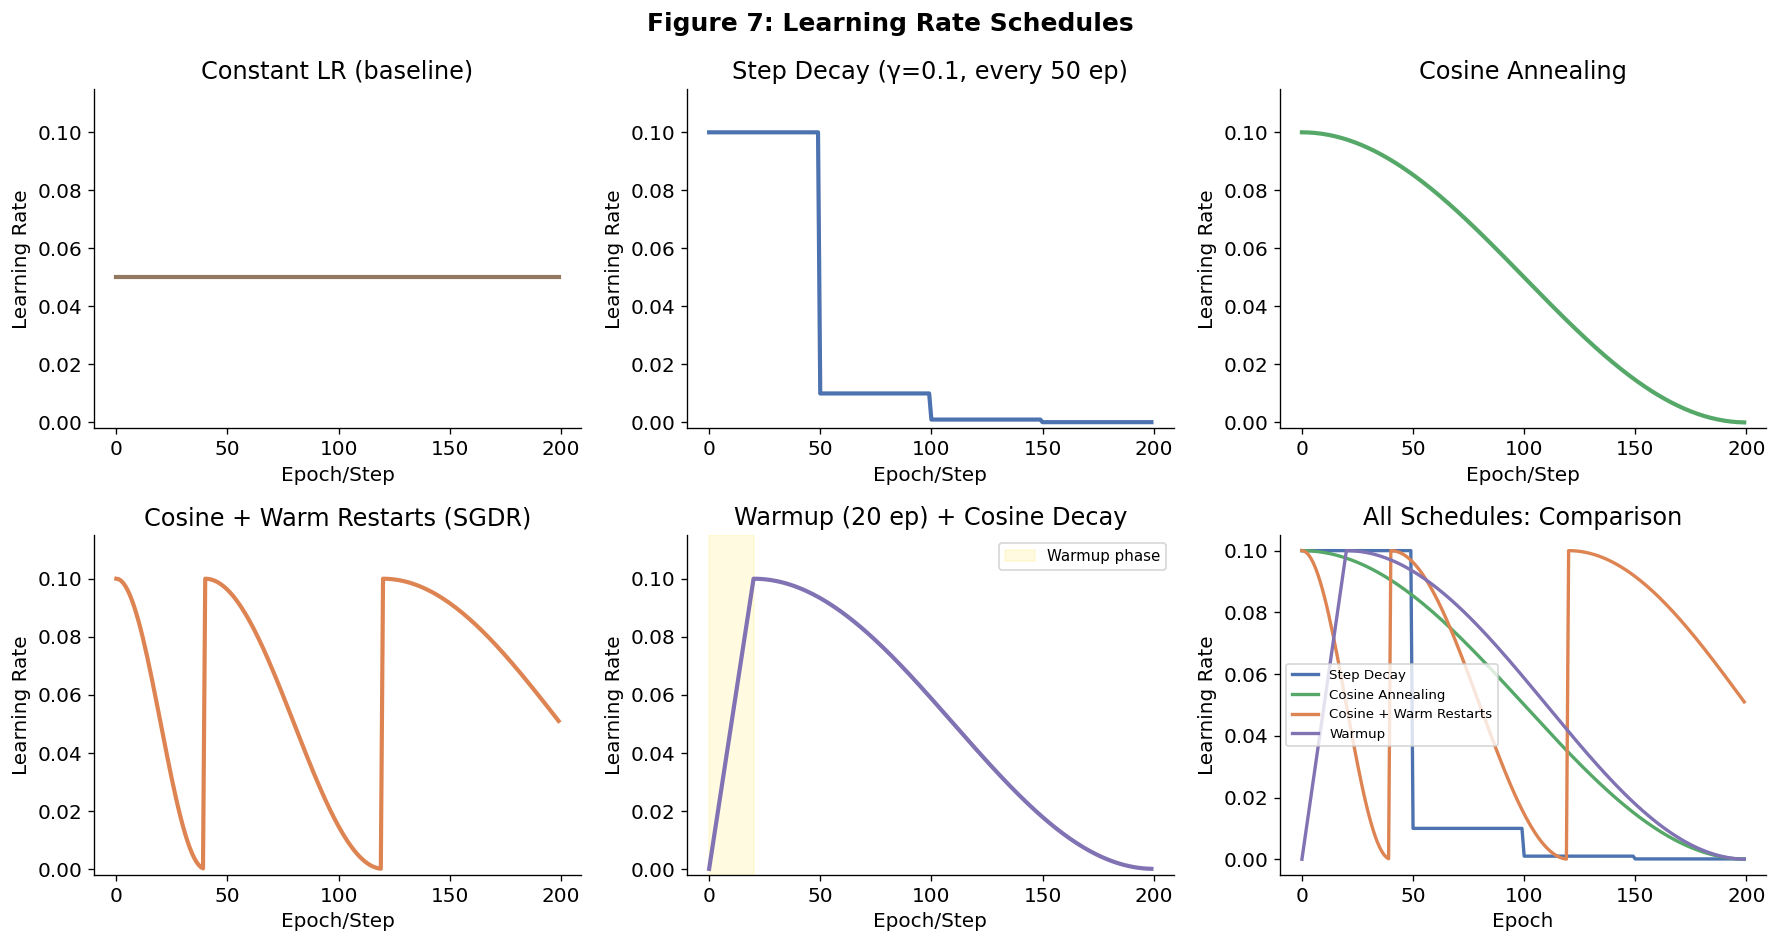

In [25]:
# Figure 7: All LR Schedules — comparison
import numpy as np
import matplotlib.pyplot as plt

T = 200   # total epochs/steps
t = np.arange(T)

# ── Step Decay ──
eta_step = 0.1 * (0.1 ** (t // 50))

# ── Cosine Annealing ──
eta_min, eta_max = 1e-5, 0.1
eta_cosine = eta_min + 0.5*(eta_max - eta_min)*(1 + np.cos(np.pi * t / T))

# ── Cosine with Warm Restarts (T0=40, T_mult=2) ──
T0 = 40
def cosine_restart(t, T0, T_mult=2, eta_min=1e-5, eta_max=0.1):
    lrs = []
    cur_T = T0
    t_cur = 0
    for ti in t:
        if t_cur >= cur_T:
            t_cur = 0
            cur_T *= T_mult
        lr = eta_min + 0.5*(eta_max-eta_min)*(1+np.cos(np.pi*t_cur/cur_T))
        lrs.append(lr)
        t_cur += 1
    return np.array(lrs)
eta_restart = cosine_restart(t, T0=40)

# ── Warmup + Cosine ──
T_warm = 20
eta_warm_cosine = np.where(
    t < T_warm,
    eta_max * t / T_warm,
    eta_min + 0.5*(eta_max-eta_min)*(1 + np.cos(np.pi*(t-T_warm)/(T-T_warm)))
)

# ── Constant (baseline) ──
eta_const = np.full(T, 0.05)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

configs = [
    (eta_const,       'Constant LR (baseline)',            '#937860'),
    (eta_step,        'Step Decay (γ=0.1, every 50 ep)',   '#4C72B0'),
    (eta_cosine,      'Cosine Annealing',                  '#55A868'),
    (eta_restart,     'Cosine + Warm Restarts (SGDR)',      '#DD8452'),
    (eta_warm_cosine, 'Warmup (20 ep) + Cosine Decay',     '#8172B3'),
]
for i, (eta, title, col) in enumerate(configs):
    axes[i].plot(t, eta, color=col, lw=2.5)
    axes[i].set_xlabel('Epoch/Step')
    axes[i].set_ylabel('Learning Rate')
    axes[i].set_title(title)
    axes[i].set_ylim(-0.002, 0.115)
    if 'Warmup' in title:
        axes[i].axvspan(0, 20, alpha=0.12, color='gold', label='Warmup phase')
        axes[i].legend(fontsize=9)

# ── Combined plot ──
for eta, title, col in configs[1:]:
    axes[5].plot(t, eta, color=col, lw=2, label=title.split('(')[0].strip())
axes[5].legend(fontsize=8); axes[5].set_title('All Schedules: Comparison')
axes[5].set_xlabel('Epoch'); axes[5].set_ylabel('Learning Rate')

plt.suptitle('Figure 7: Learning Rate Schedules', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 9. PyTorch: Optimizer + Scheduler Demo

Putting it all together: training a real network with AdamW + cosine warmup.
We'll track loss, weight norms, learning rate, and gradient norms simultaneously.


SGD                            | Final loss: 0.0155 | Accuracy: 100.0%
Adam                           | Final loss: 0.1994 | Accuracy: 99.7%
AdamW + Cosine                 | Final loss: 0.5235 | Accuracy: 94.3%
AdamW + Warmup+Cosine          | Final loss: 0.5017 | Accuracy: 96.3%


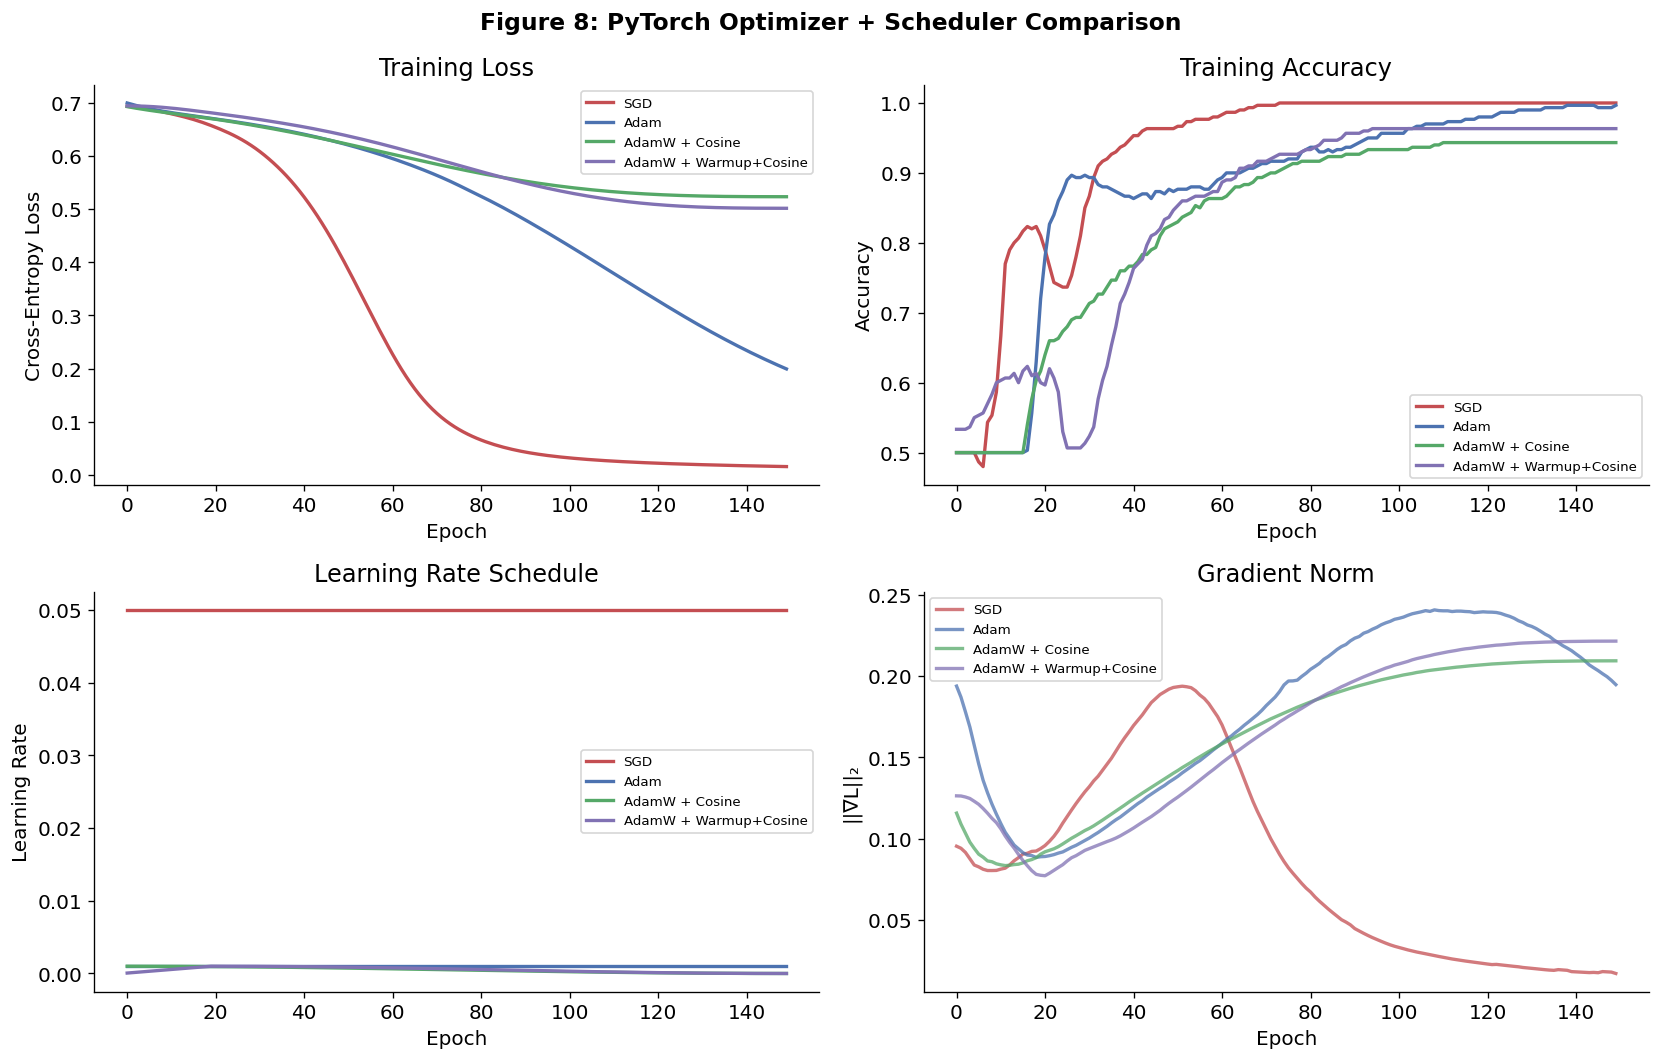

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# ── Dataset: circles (non-linear classification) ──────────────────
N = 300
theta = torch.linspace(0, 4*np.pi, N)
r_inner = 0.5 + 0.1*torch.randn(N//2)
r_outer = 1.0 + 0.1*torch.randn(N//2)
X_inner = torch.stack([r_inner*torch.cos(theta[:N//2]),
                        r_inner*torch.sin(theta[:N//2])], dim=1)
X_outer = torch.stack([r_outer*torch.cos(theta[N//2:]),
                        r_outer*torch.sin(theta[N//2:])], dim=1)
X = torch.cat([X_inner, X_outer], dim=0)
y = torch.cat([torch.zeros(N//2), torch.ones(N//2)]).long()

# ── Model ─────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 32), nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x): return self.net(x)

# ── Train with different optimizer+scheduler combos ───────────────
def train(optimizer_fn, scheduler_fn=None, epochs=150):
    model = MLP()
    opt = optimizer_fn(model.parameters())
    sch = scheduler_fn(opt) if scheduler_fn else None
    criterion = nn.CrossEntropyLoss()

    losses, accs, lrs, grad_norms = [], [], [], []
    for epoch in range(epochs):
        opt.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        # track gradient norm
        total_norm = sum(p.grad.norm()**2 for p in model.parameters() if p.grad is not None)**0.5
        grad_norms.append(total_norm.item())
        opt.step()
        if sch: sch.step()

        losses.append(loss.item())
        preds = out.argmax(dim=1)
        accs.append((preds == y).float().mean().item())
        lrs.append(opt.param_groups[0]['lr'])

    return model, losses, accs, lrs, grad_norms

T_warm = 20
epochs = 150

configs = [
    ("SGD",              lambda p: optim.SGD(p, lr=0.05, momentum=0.9),          None),
    ("Adam",             lambda p: optim.Adam(p, lr=1e-3),                        None),
    ("AdamW + Cosine",   lambda p: optim.AdamW(p, lr=1e-3, weight_decay=0.01),
     lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=epochs, eta_min=1e-6)),
    ("AdamW + Warmup+Cosine",
     lambda p: optim.AdamW(p, lr=1e-3, weight_decay=0.01),
     lambda o: optim.lr_scheduler.SequentialLR(
         o,
         [optim.lr_scheduler.LinearLR(o, start_factor=0.01, end_factor=1.0, total_iters=T_warm),
          optim.lr_scheduler.CosineAnnealingLR(o, T_max=epochs-T_warm, eta_min=1e-6)],
         milestones=[T_warm])),
]

results = {}
for name, opt_fn, sch_fn in configs:
    _, losses, accs, lrs, gnorms = train(opt_fn, sch_fn, epochs)
    results[name] = {'losses': losses, 'accs': accs, 'lrs': lrs, 'gnorms': gnorms}
    print(f"{name:30s} | Final loss: {losses[-1]:.4f} | Accuracy: {accs[-1]*100:.1f}%")

# ── Plots ──────────────────────────────────────────────────────────
colors = ['#C44E52','#4C72B0','#55A868','#8172B3']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for (name, r), col in zip(results.items(), colors):
    axes[0,0].plot(r['losses'], label=name, color=col, lw=2)
    axes[0,1].plot(r['accs'],   label=name, color=col, lw=2)
    axes[1,0].plot(r['lrs'],    label=name, color=col, lw=2)
    axes[1,1].plot(r['gnorms'], label=name, color=col, lw=2, alpha=0.75)

for ax, title, ylabel in [
    (axes[0,0], 'Training Loss',          'Cross-Entropy Loss'),
    (axes[0,1], 'Training Accuracy',      'Accuracy'),
    (axes[1,0], 'Learning Rate Schedule', 'Learning Rate'),
    (axes[1,1], 'Gradient Norm',          '||∇L||₂'),
]:
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

# ── Decision boundary ──────────────────────────────────────────────
# Re-train the best model
best_model, *_ = train(
    lambda p: optim.AdamW(p, lr=1e-3, weight_decay=0.01),
    lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=epochs, eta_min=1e-6),
    epochs=epochs
)
# (shown separately to avoid overloading the figure)

plt.suptitle('Figure 8: PyTorch Optimizer + Scheduler Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 10. Master Interview Q&A Cheatsheet

### Level 1 — Beginner

> **Q: Why can't we just use a very large learning rate for fast training?**
> A: A too-large LR causes parameter updates to overshoot the minimum — the loss oscillates or diverges. You need the LR to be small enough that each step reduces the loss. LR scheduling reduces it further as training progresses for fine-tuning.

> **Q: What does momentum do in SGD?**
> A: Maintains a velocity vector that accumulates in consistent gradient directions and dampens oscillations in noisy directions. Helps escape ravines in the loss landscape and converges faster.

> **Q: What is the difference between SGD and mini-batch SGD?**
> A: True SGD updates weights after one sample (very noisy). Mini-batch SGD processes a batch of B samples (typical: 32–256), averages their gradients, and then updates — far less noisy, exploits GPU parallelism.

> **Q: What is learning rate scheduling and why do we use it?**
> A: Systematically reducing (and sometimes cycling) the learning rate during training. High LR early = fast broad exploration; low LR late = precise convergence. Fixed LR is usually suboptimal.

---

### Level 2 — Mid-Level

> **Q: Explain Adam's two moments and how they interact in the update rule.**
> A: First moment ($m_t$, EMA of gradients) provides direction and momentum. Second moment ($v_t$, EMA of $g^2$) captures per-parameter gradient magnitude. The update $\frac{m_t}{\sqrt{v_t}+\epsilon}$ normalises momentum by gradient scale — effectively giving larger updates in directions with consistently small gradients, smaller in volatile directions.

> **Q: Why does Adam sometimes generalise worse than SGD?**
> A: Adam adapts to the training data and can converge to sharp minima that have great training loss but poor test loss. SGD+Momentum's higher noise has an implicit regularisation effect — it tends to find flatter minima. Several papers (Keskar et al., 2017; Wilson et al., 2017) demonstrated this. In practice: use Adam for speed, SGD+cosine for best final accuracy in vision.

> **Q: What is AdamW and why should it be preferred over Adam with weight_decay?**
> A: In Adam, adding weight decay via L2 adds $\lambda W$ to the gradient, which then gets scaled by the adaptive denominator. AdamW decouples weight decay — it's applied directly to weights at rate $\eta\lambda$, independent of gradient history. This ensures proper, consistent regularisation across all parameters.

> **Q: A model trained with Adam suddenly diverges after 10k steps. What do you check?**
> A: (1) Check LR — did the scheduler jump suddenly? (2) Check gradient norms per layer — is something exploding? (3) Check loss for NaN — divide by zero in activation function? (4) Check batch for degenerate examples. (5) Try adding gradient clipping (`max_norm=1.0`). (6) Try AdamW + weight decay for stability.

---

### Level 3 — Senior MLE / Staff Engineer

> **Q: Design a learning rate schedule for training a 7B parameter transformer from scratch.**
> A: (1) Linear warmup for ~2000 steps from lr=0 to peak lr ~3e-4 (or sqrt of batch size scaled). (2) Cosine decay to lr_min=3e-5 over remaining ~400k steps. (3) Use AdamW with β₁=0.9, β₂=0.95 (lower β₂ for large batch), ε=1e-8, weight_decay=0.1. (4) Clip gradients at max_norm=1.0. This is approximately the GPT-3 / LLaMA training recipe.

> **Q: What is the linear scaling rule for learning rate and when does it break?**
> A: If you multiply batch size by k, multiply learning rate by k (Goyal et al., 2017). Rationale: larger batch = lower gradient variance, so you can take larger steps. It breaks for very large batch sizes (>8k) — the linear approximation breaks down because curvature becomes significant. Solution: use LARS/LAMB optimizer for ultra-large batches.

> **Q: What is SAM (Sharpness-Aware Minimisation) and how does it relate to LR scheduling?**
> A: SAM finds parameters $W$ that lie in a flat loss neighbourhood by perturbing weights in the gradient direction, computing the loss at the perturbed point, then updating toward a solution that simultaneously minimises loss and its maximum perturbation. It explicitly seeks flat minima. LR scheduling reaches flat minima indirectly (by reducing LR ensures settling in a basin floor). SAM is more principled but 2× the compute cost.

> **Q: Compare Adam, LAMB, and LARS — when would you use each?**
> A: Adam: standard adaptive optimizer, works up to ~8k batch size. LARS (Layer-wise Adaptive Rate Scaling): used for very large batch SGD (ImageNet in 76 minutes). LAMB: Adam equivalent of LARS, per-layer adaptive rate scaling — used for BERT pretraining with batch size 64k in 76 minutes. The key insight in LARS/LAMB: normalise gradient by its L2 norm per layer, preventing large layers from dominating small ones at mega-batch scales.
